In [1]:
import pandas as pd
import numpy as np
# 读取 xlsx 文件
file_path = '副本FL接受一线免疫治疗表格.xlsx'
df = pd.read_excel(file_path)

columns_to_extract = ['ID', '性别（0:女；1:男）', '最大病灶cm（首次治疗）', 'SUVmax（首次治疗）', '治疗时ECOG（体力评分，一般>2是预后不良因素）',
                     '治疗时B症状(0:无；1:有)' ,'首次开始治疗前分期（一般1-2称为局限期，3-4进展期）', '启动一线治疗年龄（一般60为cutoff）',
                     '一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）', '一线治疗时累及淋巴结区数目（大于等于5预后不良）',
                     '治疗时是否骨髓受累（骨髓穿刺明确，有是预后不良因素）', '治疗时单个淋巴结是否大于6cm（大于6预后不良因素）', 'LDH（首次治疗）>240是预后不良因素',
                     'β2微球蛋白β2-MG（首次治疗）>3是预后不良因素', 'WBC（首次治疗）', 'HGB（首次治疗）<120是预后不良因素', 'PLT（首次治疗）',
                     '单核细胞绝对值（首次治疗）', '淋巴细胞绝对值（首次治疗）', '淋巴单核细胞比（首次治疗）',
                      '启动一线治疗原因（新补充）',
                     '分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症)',
                     '评效分组1', 'R维持分类（0:无；1:有；2:NA;3:非免疫）', '一线PFS(确诊时间-进展时间，需要写函数)', '一线后是否进展', '是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)']
extracted_data = df[columns_to_extract]

# 打印提取的数据
extracted_data


/Users/lixinze/anaconda3/envs/ml/lib/python3.7/site-packages/ipykernel_launcher.py:5: FutureWarning: Inferring datetime64[ns] from data containing strings is deprecated and will be removed in a future version. To retain the old behavior explicitly pass Series(data, dtype={value.dtype})
  """


,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,单核细胞绝对值（首次治疗）,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,R维持分类（0:无；1:有；2:NA;3:非免疫）,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,"是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)"
0,T001663640,0,2.0,NaN,0.0,0.0,1.0,30.0,3a级,2.0,...,0.36,1.51,4.194444,9：其他（请记录具体因素）,3,CR,0,41.366667,0,0
1,T001442350,0,4.3,NaN,0.0,0.0,4.0,41.0,1-2级,11.0,...,0.56,21.91,39.125000,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,31.700000,1,0
2,T001603813,1,5.0,NaN,2.0,1.0,4.0,72.0,1-2级,6.0,...,0.38,1.93,5.078947,3：B症状,3,PD,0,7.566667,1,1
3,T001299178,0,NaN,NaN,1.0,0.0,3.0,67.0,1-2级,6.0,...,NaN,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,4,CR,0,92.300000,1,0
4,T001415411,0,5.0,NaN,0.0,1.0,3.0,61.0,1-2级,4.0,...,0.93,1.93,2.075269,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,60.200000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,T001161285,0,9.4,NaN,0.0,0.0,4.0,29.0,1-2级,6.0,...,NaN,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,PR,0,12.966667,1,1
440,T001172085,0,8.5,14.6,0.0,0.0,3.0,29.0,3a级,15.0,...,0.38,1.80,4.736842,2：任何淋巴结或者结外肿块直径≥7cm,3,CR,1,13.233333,1,1
441,T001069546,1,3.6,NaN,0.0,0.0,4.0,39.0,3a级,5.0,...,NaN,NaN,NaN,9：其他（请记录具体因素）,3,CR,0,108.733333,1,0
442,T000695890,0,8.4,NaN,1.0,1.0,4.0,51.0,1-2级,6.0,...,NaN,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,CR,0,14.866667,1,1


In [2]:
data = extracted_data.copy(deep=True)

In [3]:
data['R维持分类（0:无；1:有；2:NA;3:非免疫）'].value_counts()

0    264
1    171
2      9
Name: R维持分类（0:无；1:有；2:NA;3:非免疫）, dtype: int64

In [4]:
df_filtered = data[data['R维持分类（0:无；1:有；2:NA;3:非免疫）'].isin([0, 1])]
df_filtered


,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,单核细胞绝对值（首次治疗）,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,R维持分类（0:无；1:有；2:NA;3:非免疫）,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,"是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)"
0,T001663640,0,2.0,NaN,0.0,0.0,1.0,30.0,3a级,2.0,...,0.36,1.51,4.194444,9：其他（请记录具体因素）,3,CR,0,41.366667,0,0
1,T001442350,0,4.3,NaN,0.0,0.0,4.0,41.0,1-2级,11.0,...,0.56,21.91,39.125000,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,31.700000,1,0
2,T001603813,1,5.0,NaN,2.0,1.0,4.0,72.0,1-2级,6.0,...,0.38,1.93,5.078947,3：B症状,3,PD,0,7.566667,1,1
3,T001299178,0,NaN,NaN,1.0,0.0,3.0,67.0,1-2级,6.0,...,NaN,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,4,CR,0,92.300000,1,0
4,T001415411,0,5.0,NaN,0.0,1.0,3.0,61.0,1-2级,4.0,...,0.93,1.93,2.075269,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,60.200000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,T001161285,0,9.4,NaN,0.0,0.0,4.0,29.0,1-2级,6.0,...,NaN,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,PR,0,12.966667,1,1
440,T001172085,0,8.5,14.6,0.0,0.0,3.0,29.0,3a级,15.0,...,0.38,1.80,4.736842,2：任何淋巴结或者结外肿块直径≥7cm,3,CR,1,13.233333,1,1
441,T001069546,1,3.6,NaN,0.0,0.0,4.0,39.0,3a级,5.0,...,NaN,NaN,NaN,9：其他（请记录具体因素）,3,CR,0,108.733333,1,0
442,T000695890,0,8.4,NaN,1.0,1.0,4.0,51.0,1-2级,6.0,...,NaN,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,CR,0,14.866667,1,1


In [5]:
condition = (df_filtered['一线PFS(确诊时间-进展时间，需要写函数)'] < 24) & (df_filtered['一线后是否进展'] == 0)

df_filtered = df_filtered[~condition]

df_filtered

,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,单核细胞绝对值（首次治疗）,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,R维持分类（0:无；1:有；2:NA;3:非免疫）,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,"是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)"
0,T001663640,0,2.0,NaN,0.0,0.0,1.0,30.0,3a级,2.0,...,0.36,1.51,4.194444,9：其他（请记录具体因素）,3,CR,0,41.366667,0,0
1,T001442350,0,4.3,NaN,0.0,0.0,4.0,41.0,1-2级,11.0,...,0.56,21.91,39.125000,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,31.700000,1,0
2,T001603813,1,5.0,NaN,2.0,1.0,4.0,72.0,1-2级,6.0,...,0.38,1.93,5.078947,3：B症状,3,PD,0,7.566667,1,1
3,T001299178,0,NaN,NaN,1.0,0.0,3.0,67.0,1-2级,6.0,...,NaN,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,4,CR,0,92.300000,1,0
4,T001415411,0,5.0,NaN,0.0,1.0,3.0,61.0,1-2级,4.0,...,0.93,1.93,2.075269,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,60.200000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,T008017941,1,8.7,NaN,0.0,0.0,2.0,56.0,1-2级,3.0,...,NaN,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,PR,0,15.633333,1,1
439,T001161285,0,9.4,NaN,0.0,0.0,4.0,29.0,1-2级,6.0,...,NaN,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,PR,0,12.966667,1,1
440,T001172085,0,8.5,14.6,0.0,0.0,3.0,29.0,3a级,15.0,...,0.38,1.80,4.736842,2：任何淋巴结或者结外肿块直径≥7cm,3,CR,1,13.233333,1,1
441,T001069546,1,3.6,NaN,0.0,0.0,4.0,39.0,3a级,5.0,...,NaN,NaN,NaN,9：其他（请记录具体因素）,3,CR,0,108.733333,1,0


In [6]:
df_filtered['是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)'].value_counts()

0    278
1    131
4      1
Name: 是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA), dtype: int64

In [7]:
df_filtered = df_filtered[df_filtered['是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)'].isin([0, 1])]

In [8]:
df_filtered.rename(columns={'R维持分类（0:无；1:有；2:NA;3:非免疫）': 'Rweichi', '是否POD24(0=无，1=是,2=非免疫化疗，3=随访<24个月，4=NA)': 'pod24'}, inplace=True)
df_filtered

/Users/lixinze/anaconda3/envs/ml/lib/python3.7/site-packages/pandas/core/frame.py:5047: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,单核细胞绝对值（首次治疗）,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,Rweichi,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,pod24
0,T001663640,0,2.0,NaN,0.0,0.0,1.0,30.0,3a级,2.0,...,0.36,1.51,4.194444,9：其他（请记录具体因素）,3,CR,0,41.366667,0,0
1,T001442350,0,4.3,NaN,0.0,0.0,4.0,41.0,1-2级,11.0,...,0.56,21.91,39.125000,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,31.700000,1,0
2,T001603813,1,5.0,NaN,2.0,1.0,4.0,72.0,1-2级,6.0,...,0.38,1.93,5.078947,3：B症状,3,PD,0,7.566667,1,1
3,T001299178,0,NaN,NaN,1.0,0.0,3.0,67.0,1-2级,6.0,...,NaN,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,4,CR,0,92.300000,1,0
4,T001415411,0,5.0,NaN,0.0,1.0,3.0,61.0,1-2级,4.0,...,0.93,1.93,2.075269,1：受累淋巴结区≥3个，直径≥3cm,3,PR,0,60.200000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,T008017941,1,8.7,NaN,0.0,0.0,2.0,56.0,1-2级,3.0,...,NaN,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,PR,0,15.633333,1,1
439,T001161285,0,9.4,NaN,0.0,0.0,4.0,29.0,1-2级,6.0,...,NaN,NaN,NaN,2：任何淋巴结或者结外肿块直径≥7cm,3,PR,0,12.966667,1,1
440,T001172085,0,8.5,14.6,0.0,0.0,3.0,29.0,3a级,15.0,...,0.38,1.80,4.736842,2：任何淋巴结或者结外肿块直径≥7cm,3,CR,1,13.233333,1,1
441,T001069546,1,3.6,NaN,0.0,0.0,4.0,39.0,3a级,5.0,...,NaN,NaN,NaN,9：其他（请记录具体因素）,3,CR,0,108.733333,1,0


In [9]:
df_filtered['启动一线治疗原因（新补充）'].value_counts()

2：任何淋巴结或者结外肿块直径≥7cm                118
9：其他（请记录具体因素）                       96
1：受累淋巴结区≥3个，直径≥3cm                  58
8：患者意愿                              51
4：脾大                                41
5：胸腔积液、腹水                           12
3：B症状                                8
6：白细胞＜1.0x10^9/L或血小板＜100x10^9/L      5
7：白血病（恶性细胞＞5x10^9/L）                 3
Name: 启动一线治疗原因（新补充）, dtype: int64

In [10]:
# 定义映射字典
mapping_dict = {
#                 '2：任何淋巴结或者结外肿块直径≥7cm': 2, 
                '4：脾大': 4, 
#                 '9：其他（请记录具体因素）':9,
#                '1：受累淋巴结区≥3个，直径≥3cm':1, '8：患者意愿':8, '5：胸腔积液、腹水':5,
#                '3：B症状':3, '6：白细胞＜1.0x10^9/L或血小板＜100x10^9/L':6, '7：白血病（恶性细胞＞5x10^9/L）':7
}

df_filtered['启动一线治疗原因（新补充）'] = df_filtered['启动一线治疗原因（新补充）'].map(mapping_dict)

df_filtered

/Users/lixinze/anaconda3/envs/ml/lib/python3.7/site-packages/ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Remove the CWD from sys.path while we load stuff.


,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,单核细胞绝对值（首次治疗）,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,Rweichi,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,pod24
0,T001663640,0,2.0,NaN,0.0,0.0,1.0,30.0,3a级,2.0,...,0.36,1.51,4.194444,NaN,3,CR,0,41.366667,0,0
1,T001442350,0,4.3,NaN,0.0,0.0,4.0,41.0,1-2级,11.0,...,0.56,21.91,39.125000,NaN,3,PR,0,31.700000,1,0
2,T001603813,1,5.0,NaN,2.0,1.0,4.0,72.0,1-2级,6.0,...,0.38,1.93,5.078947,NaN,3,PD,0,7.566667,1,1
3,T001299178,0,NaN,NaN,1.0,0.0,3.0,67.0,1-2级,6.0,...,NaN,NaN,NaN,NaN,4,CR,0,92.300000,1,0
4,T001415411,0,5.0,NaN,0.0,1.0,3.0,61.0,1-2级,4.0,...,0.93,1.93,2.075269,NaN,3,PR,0,60.200000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,T008017941,1,8.7,NaN,0.0,0.0,2.0,56.0,1-2级,3.0,...,NaN,NaN,NaN,NaN,3,PR,0,15.633333,1,1
439,T001161285,0,9.4,NaN,0.0,0.0,4.0,29.0,1-2级,6.0,...,NaN,NaN,NaN,NaN,3,PR,0,12.966667,1,1
440,T001172085,0,8.5,14.6,0.0,0.0,3.0,29.0,3a级,15.0,...,0.38,1.80,4.736842,NaN,3,CR,1,13.233333,1,1
441,T001069546,1,3.6,NaN,0.0,0.0,4.0,39.0,3a级,5.0,...,NaN,NaN,NaN,NaN,3,CR,0,108.733333,1,0


In [11]:
df_filtered['启动一线治疗原因（新补充）'].value_counts()

4.0    41
Name: 启动一线治疗原因（新补充）, dtype: int64

In [12]:
con_features = ['最大病灶cm（首次治疗）', 'SUVmax（首次治疗）', 
                     '启动一线治疗年龄（一般60为cutoff）',
                     '一线治疗时累及淋巴结区数目（大于等于5预后不良）',
                       'LDH（首次治疗）>240是预后不良因素',
                     'β2微球蛋白β2-MG（首次治疗）>3是预后不良因素', 'WBC（首次治疗）', 'HGB（首次治疗）<120是预后不良因素', 'PLT（首次治疗）',
                     '单核细胞绝对值（首次治疗）', '淋巴细胞绝对值（首次治疗）', '淋巴单核细胞比（首次治疗）']
cate_features = ['性别（0:女；1:男）', '一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）', '治疗时ECOG（体力评分，一般>2是预后不良因素）', '治疗时B症状(0:无；1:有)' , '首次开始治疗前分期（一般1-2称为局限期，3-4进展期）', 
               '治疗时是否骨髓受累（骨髓穿刺明确，有是预后不良因素）', '治疗时单个淋巴结是否大于6cm（大于6预后不良因素）',
                '分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症)', '评效分组1',
                '启动一线治疗原因（新补充）']

In [13]:
from sklearn.preprocessing import LabelEncoder
labelEncoderDict = {}
for f in cate_features:
    le = LabelEncoder()
    labelEncoderDict[f] = {}
    df_filtered[f] = le.fit_transform(df_filtered[f])
    clas = le.classes_
    for i in range(0, len(clas)):
        labelEncoderDict[f][clas[i]] = i
    df_filtered[f] = df_filtered[f].astype('Int64')
print(labelEncoderDict)

{'性别（0:女；1:男）': {0: 0, 1: 1}, '一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）': {'1-2级': 0, '1-2级，局灶3a级': 1, '3a级': 2, '3a级，可能有转化': 3, '3b级': 4, '3级': 5, '3级 ': 6, 'TFL,DLBCL': 7, 'tFL,DLBCL': 8, nan: 9}, '治疗时ECOG（体力评分，一般>2是预后不良因素）': {0.0: 0, 1.0: 1, 2.0: 2, 3.0: 3, 4.0: 4, nan: 5}, '治疗时B症状(0:无；1:有)': {0.0: 0, 1.0: 1, nan: 2}, '首次开始治疗前分期（一般1-2称为局限期，3-4进展期）': {0.0: 0, 1.0: 1, 2.0: 2, 3.0: 3, 4.0: 4, nan: 5}, '治疗时是否骨髓受累（骨髓穿刺明确，有是预后不良因素）': {0.0: 0, 1.0: 1, nan: 2}, '治疗时单个淋巴结是否大于6cm（大于6预后不良因素）': {0.0: 0, 1.0: 1, nan: 2}, '分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症)': {1: 0, 3: 1, 4: 2, 6: 3, 9: 4, 10: 5, 11: 6}, '评效分组1': {'CR': 0, 'PD': 1, 'PR': 2, 'SD': 3, nan: 4}, '启动一线治疗原因（新补充）': {4.0: 0, nan: 1}}


/Users/lixinze/anaconda3/envs/ml/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/Users/lixinze/anaconda3/envs/ml/lib/python3.7/site-packages/ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Remove the CWD from sys.path while we load stuff.


In [14]:
from sklift.metrics import qini_auc_score, uplift_auc_score, uplift_at_k, uplift_by_percentile
from sklift.viz import plot_uplift_by_percentile
from sklift.viz import plot_qini_curve, plot_uplift_curve
def get_qini_curves(y_test, uplift_slearner, trmnt_test):
    fig, ax = plt.subplots(1, 1)
    ax.set_title('Qini Curve for Testing Set')
    
    plot_qini_curve(y_test, uplift_slearner, trmnt_test, perfect=False, name='X', ax=ax)

In [15]:
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import roc_auc_score, recall_score, precision_score
class Binary_Treatment_DML():
    def __init__(self,df_train,df_test,cat_features,con_features,y_model_conf,t_model_conf,res_model_conf,kfold,Y,T):
        self.df_train,self.df_test = df_train,df_test
        self.cat_features,self.con_features = cat_features,con_features
        self.features = cat_features + con_features
        self.y_model_conf,self.t_model_conf,self.res_model_conf = y_model_conf,t_model_conf,res_model_conf
        self.kfold = kfold # kfold cross fit
        self.Y,self.T = Y,T # Y~outcome, T~treatment
        self.res_model = CatBoostRegressor(**res_model_conf) # residual model using catboost(deal with categorical features)
        self.y_model = None
        
    def first_stage_fit(self,df_train,df_pred):
        # T_train = df_train[df_train[self.T]==1] # treatment group train
        # C_train = df_train[df_train[self.T]==0].sample(n=T_train.shape[0]) # control group train
        # T_pred = df_pred[df_pred[self.T]==1] # treatment group predict
        # C_pred = df_pred[df_pred[self.T]==0].sample(n=T_pred.shape[0]) # control group predict
        # df_train = pd.concat([T_train,C_train],axis=0) # concat train df
        # df_pred = pd.concat([T_pred,C_pred],axis=0) # concat pred df
        self.y_model = CatBoostClassifier(**self.y_model_conf).fit(df_train[self.features], df_train[self.Y])
        t_model = CatBoostClassifier(**self.t_model_conf).fit(df_train[self.features], df_train[self.T])

        y_pred = self.y_model.predict_proba(df_pred[self.features])[:, 1]
        y_model_train_auc = roc_auc_score(df_train[self.Y], self.y_model.predict(df_train[self.features]))
        y_model_train_precision = precision_score(df_train[self.Y], self.y_model.predict(df_train[self.features]))
        y_model_train_recall = recall_score(df_train[self.Y], self.y_model.predict(df_train[self.features]))
        y_model_pred_auc = roc_auc_score(df_pred[self.Y], self.y_model.predict(df_pred[self.features]))
        y_model_pred_precision = precision_score(df_pred[self.Y], self.y_model.predict(df_pred[self.features]))
        y_model_pred_recall = recall_score(df_pred[self.Y], self.y_model.predict(df_pred[self.features]))
        print({'Y Model Train AUC': y_model_train_auc, 'Y Model Train Precision': y_model_train_precision, 'Y Model Train Recall': y_model_train_recall})
        print({'Y Model Test AUC': y_model_pred_auc, 'Y Model Test Precision': y_model_pred_precision, 'Y Model Test Recall': y_model_pred_recall})

        t_pred = t_model.predict_proba(df_pred[self.features])[:, 1]
        t_model_train_auc = roc_auc_score(df_train[self.T], t_model.predict(df_train[self.features]))
        t_model_train_precision = precision_score(df_train[self.T], t_model.predict(df_train[self.features]))
        t_model_train_recall = recall_score(df_train[self.T], t_model.predict(df_train[self.features]))
        t_model_pred_auc = roc_auc_score(df_pred[self.T], t_model.predict(df_pred[self.features]))
        t_model_pred_precision = precision_score(df_pred[self.T], t_model.predict(df_pred[self.features]))
        t_model_pred_recall = recall_score(df_pred[self.T], t_model.predict(df_pred[self.features]))
        print({'T Model Train AUC': t_model_train_auc, 'T Model Train Precision': t_model_train_precision, 'T Model Train Recall': t_model_train_recall})
        print({'T Model Test AUC': t_model_pred_auc, 'T Model Test Precision': t_model_pred_precision, 'T Model Test Recall': t_model_pred_recall})
        
        y_res = np.array(df_pred[self.Y]) - y_pred
        t_res = np.array(df_pred[self.T]) - t_pred
        sample_weight = t_res**2 # non-params model sample weight
        res_label = y_res / t_res # res model fit on residual ratio
        return sample_weight,res_label,df_pred

    def res_model_prep(self,df_all):
        sample_weight_final = np.array([])
        res_label_final = np.array([])
        df_final = pd.DataFrame()
        kf = KFold(n_splits=self.kfold, shuffle=True,random_state=0)
        for train_index,pred_index in kf.split(df_all):
            df_train, df_pred = df_all.iloc[train_index].reset_index(drop=True), df_all.iloc[pred_index].reset_index(drop=True)
            sample_weight,res_label,df_pred = self.first_stage_fit(df_train,df_pred)
            sample_weight_final = np.concatenate([sample_weight_final,sample_weight],axis=0)
            res_label_final = np.concatenate([res_label_final,res_label],axis=0)
            df_final = df_final.append(df_pred)
        return sample_weight_final,res_label_final,df_final

    def fit(self):
        sample_weight_final,res_label_final,df_final = self.res_model_prep(self.df_train)
        self.res_model.fit(df_final[self.features],res_label_final,sample_weight=sample_weight_final)

    def predict_outcome(self, data):
        return self.y_model.predict_proba(data[self.features])[:, 1]
    
    def predict(self,data):
        return self.res_model.predict(data[self.features])
    
    def get_feature_importance(self):
        Feature = pd.DataFrame()
        f_i = self.res_model.get_feature_importance()
        Feature['feature'] = self.features
        Feature['importance'] = f_i
        return Feature.sort_values(by='importance',ascending=False)

In [16]:

y_model_conf = {
    "iterations": 100,
    "learning_rate":0.03,
    "depth":6,
#     "rsm":0.5,
#     "border_count":10,
#     "metric_period":5,
#     "subsample":0.2,
    "cat_features":cate_features,
    "auto_class_weights": 'Balanced'
}
t_model_conf = {
    "iterations": 100,
    "learning_rate":0.03,
    "depth":6,
#     "rsm":0.5,
#     "border_count":10,
#     "metric_period":5,
#     "subsample":0.2,
    "cat_features":cate_features,
    "auto_class_weights": 'Balanced'
}
res_model_conf = {
    "iterations": 100,
    "learning_rate":0.03,
    "depth":6,
#     "rsm":0.5,
#     "border_count":10,
#     "metric_period":5,
#     "subsample":0.2,
    "cat_features":cate_features,
}

In [17]:
from sklearn.model_selection import train_test_split
df_filtered[cate_features] = df_filtered[cate_features].astype('str')
df_train, df_test = train_test_split(df_filtered, test_size=0.2, random_state=6)

/Users/lixinze/anaconda3/envs/ml/lib/python3.7/site-packages/pandas/core/frame.py:3641: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]


In [18]:
from sklearn.model_selection import KFold
DML = Binary_Treatment_DML(df_train=df_train, df_test=df_test, cat_features=cate_features, con_features=con_features,
                          y_model_conf=y_model_conf, t_model_conf=t_model_conf, res_model_conf=res_model_conf, kfold=3,
                          Y='pod24', T='Rweichi')

In [19]:
DML.fit()

0:	learn: 0.6722957	total: 55.5ms	remaining: 5.5s
1:	learn: 0.6588181	total: 58.3ms	remaining: 2.86s
2:	learn: 0.6451128	total: 60.3ms	remaining: 1.95s
3:	learn: 0.6342622	total: 62.3ms	remaining: 1.49s
4:	learn: 0.6238682	total: 64ms	remaining: 1.22s
5:	learn: 0.6091248	total: 65.5ms	remaining: 1.03s
6:	learn: 0.5929887	total: 66.9ms	remaining: 889ms
7:	learn: 0.5802598	total: 68.4ms	remaining: 787ms
8:	learn: 0.5728873	total: 69.6ms	remaining: 704ms
9:	learn: 0.5620367	total: 71.2ms	remaining: 641ms
10:	learn: 0.5550627	total: 73.1ms	remaining: 591ms
11:	learn: 0.5466916	total: 74.7ms	remaining: 548ms
12:	learn: 0.5408786	total: 76.3ms	remaining: 511ms
13:	learn: 0.5332642	total: 78.2ms	remaining: 480ms
14:	learn: 0.5251945	total: 79.8ms	remaining: 452ms
15:	learn: 0.5175790	total: 80.9ms	remaining: 425ms
16:	learn: 0.5090079	total: 82.3ms	remaining: 402ms
17:	learn: 0.5022811	total: 83.8ms	remaining: 382ms
18:	learn: 0.4951414	total: 85.5ms	remaining: 365ms
19:	learn: 0.4878808	tota

{'T Model Train AUC': 0.907878787878788, 'T Model Train Precision': 0.8395061728395061, 'T Model Train Recall': 0.9066666666666666}
{'T Model Test AUC': 0.5813049357674105, 'T Model Test Precision': 0.5681818181818182, 'T Model Test Recall': 0.49019607843137253}
0:	learn: 0.6769166	total: 2.86ms	remaining: 283ms
1:	learn: 0.6657626	total: 5.28ms	remaining: 258ms
2:	learn: 0.6527210	total: 8.11ms	remaining: 262ms
3:	learn: 0.6372931	total: 9.77ms	remaining: 234ms
4:	learn: 0.6267476	total: 12.4ms	remaining: 236ms
5:	learn: 0.6161463	total: 14.2ms	remaining: 223ms
6:	learn: 0.6063482	total: 15.8ms	remaining: 210ms
7:	learn: 0.5938832	total: 18.4ms	remaining: 212ms
8:	learn: 0.5831004	total: 20.4ms	remaining: 207ms
9:	learn: 0.5760660	total: 22.1ms	remaining: 199ms
10:	learn: 0.5664000	total: 24.3ms	remaining: 197ms
11:	learn: 0.5555940	total: 25.9ms	remaining: 190ms
12:	learn: 0.5463680	total: 27.8ms	remaining: 186ms
13:	learn: 0.5380685	total: 29.4ms	remaining: 180ms
14:	learn: 0.529727

97:	learn: 0.3863041	total: 192ms	remaining: 3.91ms
98:	learn: 0.3849976	total: 195ms	remaining: 1.97ms
99:	learn: 0.3824161	total: 197ms	remaining: 0us
{'Y Model Train AUC': 0.8992156862745098, 'Y Model Train Precision': 0.7848101265822784, 'Y Model Train Recall': 0.9117647058823529}
{'Y Model Test AUC': 0.7971042471042471, 'Y Model Test Precision': 0.7027027027027027, 'Y Model Test Recall': 0.7428571428571429}
{'T Model Train AUC': 0.8903655913978494, 'T Model Train Precision': 0.8269230769230769, 'T Model Train Recall': 0.9247311827956989}
{'T Model Test AUC': 0.5127591706539075, 'T Model Test Precision': 0.3170731707317073, 'T Model Test Recall': 0.3939393939393939}
0:	learn: 0.6741202	total: 2.52ms	remaining: 249ms
1:	learn: 0.6600092	total: 4.66ms	remaining: 228ms
2:	learn: 0.6452537	total: 6.8ms	remaining: 220ms
3:	learn: 0.6329361	total: 8.84ms	remaining: 212ms
4:	learn: 0.6162246	total: 11.6ms	remaining: 220ms
5:	learn: 0.6042106	total: 13.8ms	remaining: 216ms
6:	learn: 0.5879

46:	learn: 0.5229399	total: 86.9ms	remaining: 98ms
47:	learn: 0.5229393	total: 87.8ms	remaining: 95.2ms
48:	learn: 0.5200362	total: 90.3ms	remaining: 94ms
49:	learn: 0.5125484	total: 92ms	remaining: 92ms
50:	learn: 0.5102309	total: 93.2ms	remaining: 89.6ms
51:	learn: 0.5066836	total: 95ms	remaining: 87.6ms
52:	learn: 0.5037180	total: 96.7ms	remaining: 85.8ms
53:	learn: 0.5007055	total: 98.3ms	remaining: 83.7ms
54:	learn: 0.4992823	total: 99.8ms	remaining: 81.7ms
55:	learn: 0.4982288	total: 102ms	remaining: 79.8ms
56:	learn: 0.4961757	total: 103ms	remaining: 77.8ms
57:	learn: 0.4947434	total: 104ms	remaining: 75.6ms
58:	learn: 0.4926272	total: 106ms	remaining: 73.7ms
59:	learn: 0.4882818	total: 108ms	remaining: 72.1ms
60:	learn: 0.4855792	total: 110ms	remaining: 70.4ms
61:	learn: 0.4848312	total: 112ms	remaining: 68.8ms
62:	learn: 0.4814809	total: 114ms	remaining: 67.2ms
63:	learn: 0.4797514	total: 117ms	remaining: 65.9ms
64:	learn: 0.4775314	total: 119ms	remaining: 64.1ms
65:	learn: 0.

In [20]:
df_filtered['uplift'] = DML.predict(df_filtered)
final = df_filtered[['ID', 'Rweichi', 'pod24', 'uplift']].copy(deep=True)

/Users/lixinze/anaconda3/envs/ml/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [21]:
def response_uplift_by_percentile(y_val, uplift_predictions, treat_val, group, bins=10):
    y_true, uplift, treatment = np.array(y_val), np.array(uplift_predictions), np.array(treat_val)
    order = np.argsort(uplift, kind='mergesort')[::-1]
    
    y_true_bin = np.array_split(y_true[order], bins)
    trmnt_bin = np.array_split(treatment[order], bins)
    uplift_bin = np.array_split(uplift[order], bins)
    
    trmnt_flag = 1 if group == 'treatment' else 0
    
    group_size = np.array([len(y[trmnt == trmnt_flag]) for y, trmnt in zip(y_true_bin, trmnt_bin)])
    response_rate = np.array([np.mean(y[trmnt == trmnt_flag]) for y, trmnt in zip(y_true_bin, trmnt_bin)])
    uplift_mean = np.array([np.mean(y[trmnt == trmnt_flag]) for y, trmnt in zip(uplift_bin, trmnt_bin)])
    
    return response_rate, uplift_mean, group_size

def uplift_by_deciles(y_val, uplift_predictions, treat_val, bins=10):
    y_val, uplift_predictions, treat_val = np.array(y_val), np.array(uplift_predictions), np.array(treat_val)
    
    response_rate_trmnt, uplift_mean_trmnt, n_trmnt = response_uplift_by_percentile(y_val, uplift_predictions, treat_val, group='treatment', bins=bins)
    response_rate_ctrl, uplift_mean_ctrl, n_ctrl = response_uplift_by_percentile(y_val, uplift_predictions, treat_val, group='control', bins=bins)
    
    actual_uplift_scores = response_rate_trmnt - response_rate_ctrl
    predicted_uplift_scores = (uplift_mean_trmnt*n_trmnt + uplift_mean_ctrl*n_ctrl) / (n_trmnt + n_ctrl)
    
    percentiles = [round(p*100/bins) for p in range(1, bins+1)]
    percentiles = [f"0-{percentiles[0]}"] + [f"{percentiles[i]}-{percentiles[i+1]}" for i in range(len(percentiles)-1)]
    
    df = pd.DataFrame({
        'percentile':percentiles,
        'n_treatment': n_trmnt,
        'n_control':n_ctrl,
        'response_rate_treatment': response_rate_trmnt,
        'response_rate_control': response_rate_ctrl,
        'actual_uplift_scores': actual_uplift_scores,
        'uplift_mean_treatment': uplift_mean_trmnt,
        'uplift_mean_control': uplift_mean_ctrl,
        'predicted_uplift_scores': predicted_uplift_scores
    })
    
    return df

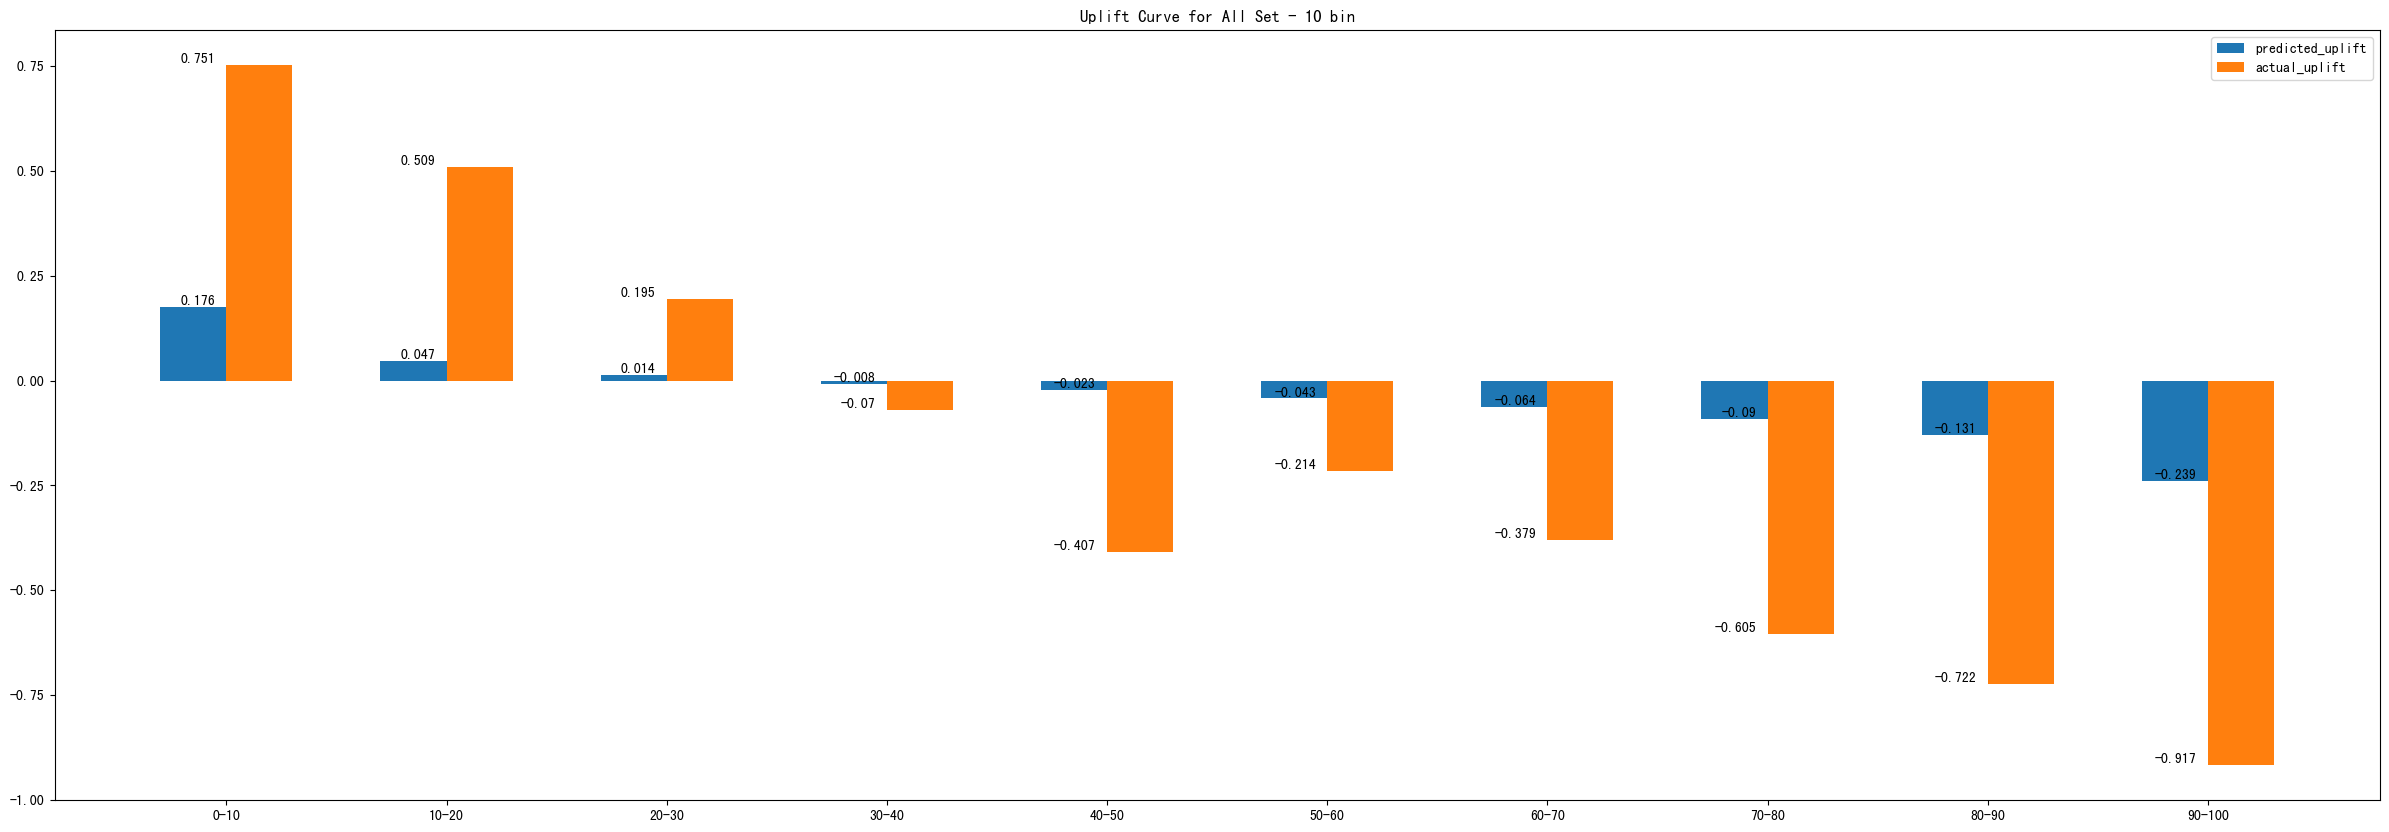

In [22]:
import matplotlib.pyplot as plt
df_bin = uplift_by_deciles(final['pod24'], final['uplift'], final['Rweichi'], bins=10)
df_bin

plt.figure(figsize=[30, 10])
bar_width=0.3
x = np.arange(10)

tick_label = df_bin['percentile']
plt.bar(x, df_bin['predicted_uplift_scores'], bar_width, label='predicted_uplift')
for a, b in enumerate(df_bin['predicted_uplift_scores'].values):
    plt.text(a+0.1, b, round(float(b), 3), ha='right', va='bottom')
plt.bar(x + bar_width, df_bin['actual_uplift_scores'], bar_width, label='actual_uplift')
for a, b in enumerate(df_bin['actual_uplift_scores'].values):
    plt.text(a+0.1, b, round(float(b), 3), ha='right', va='bottom')  

plt.legend()
plt.xticks(x+bar_width/2, tick_label)
plt.title('Uplift Curve for All Set - 10 bin')
plt.show()

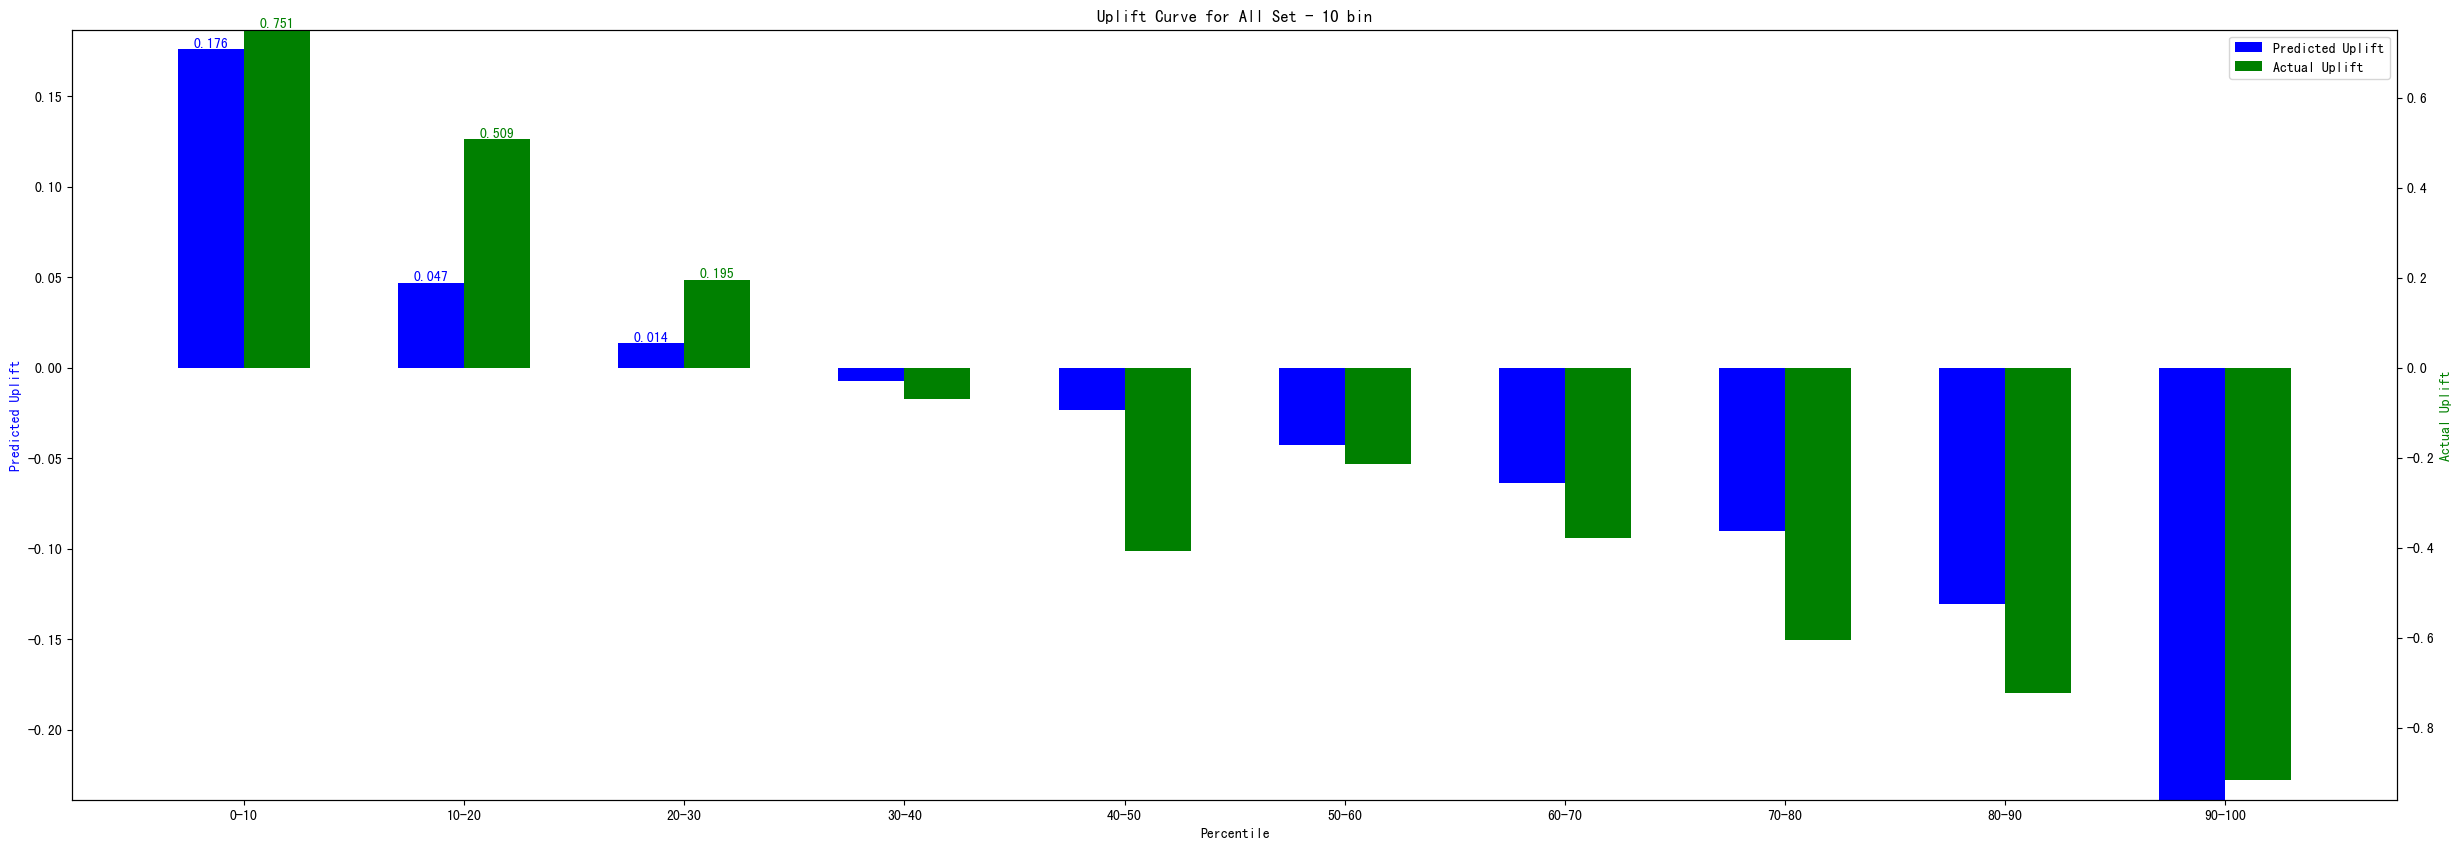

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 假设 uplift_by_deciles 函数和数据 df_bin 已经定义
df_bin = uplift_by_deciles(final['pod24'], final['uplift'], final['Rweichi'], bins=10)

fig, ax1 = plt.subplots(figsize=[30, 10])
bar_width = 0.3
x = np.arange(10)

tick_label = df_bin['percentile']

# 绘制第一个柱状图，使用左侧y轴
predicted_uplift = df_bin['predicted_uplift_scores']
actual_uplift = df_bin['actual_uplift_scores']

ax1.bar(x, predicted_uplift, bar_width, label='Predicted Uplift', color='b')
for a, b in enumerate(predicted_uplift.values):
    ax1.text(a, b, round(float(b), 3), ha='center', va='bottom', color='b')

# 创建第二个y轴，分享相同的x轴
ax2 = ax1.twinx()
ax2.bar(x + bar_width, actual_uplift, bar_width, label='Actual Uplift', color='g')
for a, b in enumerate(actual_uplift.values):
    ax2.text(a + bar_width, b, round(float(b), 3), ha='center', va='bottom', color='g')

# 设置y轴范围，以使0值对齐
max_predicted = max(predicted_uplift)
min_predicted = min(predicted_uplift)
max_actual = max(actual_uplift)
min_actual = min(actual_uplift)

# 找到两个y轴的比例
ratio = (max_predicted - min_predicted) / (max_actual - min_actual)

# 设置y轴范围
ax1.set_ylim(min(min_predicted, min_actual * ratio), max(max_predicted, max_actual * ratio))
ax2.set_ylim(min(min_actual, min_predicted / ratio), max(max_actual, max_predicted / ratio))

# 设置标签和标题
ax1.set_xlabel('Percentile')
ax1.set_ylabel('Predicted Uplift', color='b')
ax2.set_ylabel('Actual Uplift', color='g')

# 设置x轴刻度标签
plt.xticks(x + bar_width / 2, tick_label)

# 设置图例
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

plt.title('Uplift Curve for All Set - 10 bin')
plt.show()


In [24]:
print(np.mean(DML.predict(df_train)))
print(np.mean(DML.predict(df_test)))
print(np.mean(DML.predict(df_filtered)))

-0.034923041983645334
-0.038028247268991296
-0.03554560147850687


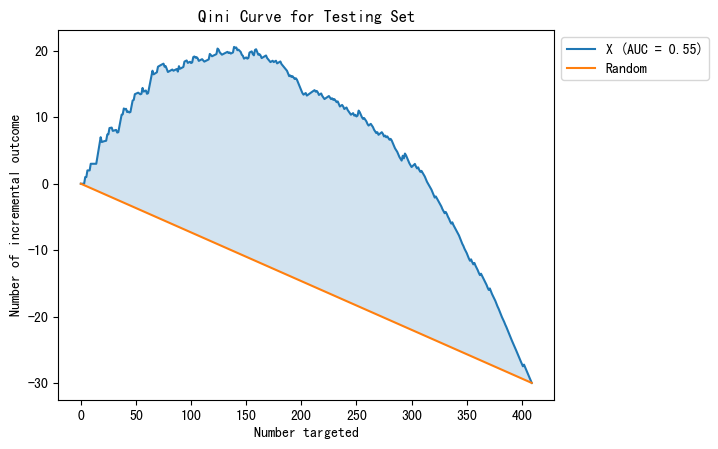

In [25]:
get_qini_curves(df_filtered['pod24'], DML.predict(df_filtered), df_filtered['Rweichi'])

In [26]:
DML.get_feature_importance()

,feature,importance
14,LDH（首次治疗）>240是预后不良因素,9.827863
6,治疗时单个淋巴结是否大于6cm（大于6预后不良因素）,9.243825
15,β2微球蛋白β2-MG（首次治疗）>3是预后不良因素,9.222254
10,最大病灶cm（首次治疗）,8.742045
12,启动一线治疗年龄（一般60为cutoff）,8.651900
21,淋巴单核细胞比（首次治疗）,6.372196
11,SUVmax（首次治疗）,6.193651
18,PLT（首次治疗）,5.584441
13,一线治疗时累及淋巴结区数目（大于等于5预后不良）,5.145022
3,治疗时B症状(0:无；1:有),4.859258


In [27]:
df_bin

,percentile,n_treatment,n_control,response_rate_treatment,response_rate_control,actual_uplift_scores,uplift_mean_treatment,uplift_mean_control,predicted_uplift_scores
0,0-10,15,26,0.866667,0.115385,0.751282,0.167979,0.180679,0.176033
1,10-20,12,29,0.750000,0.241379,0.508621,0.052663,0.044564,0.046935
2,20-30,12,29,0.333333,0.137931,0.195402,0.012150,0.014068,0.013507
3,30-40,16,25,0.250000,0.320000,-0.070000,-0.006792,-0.008091,-0.007584
4,40-50,14,27,0.000000,0.407407,-0.407407,-0.023058,-0.023342,-0.023245
5,50-60,13,28,0.000000,0.214286,-0.214286,-0.044202,-0.041850,-0.042596
6,60-70,18,23,0.055556,0.434783,-0.379227,-0.063825,-0.063423,-0.063599
7,70-80,21,20,0.095238,0.700000,-0.604762,-0.091536,-0.089286,-0.090438
8,80-90,23,18,0.000000,0.722222,-0.722222,-0.131867,-0.129138,-0.130669
9,90-100,16,24,0.000000,0.916667,-0.916667,-0.230368,-0.244348,-0.238756


In [28]:
df_filtered

,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,Rweichi,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,pod24,uplift
0,T001663640,0,2.0,NaN,0,0,1,30.0,2,2.0,...,1.51,4.194444,1,1,0,0,41.366667,0,0,0.039183
1,T001442350,0,4.3,NaN,0,0,4,41.0,0,11.0,...,21.91,39.125000,1,1,2,0,31.700000,1,0,0.100634
2,T001603813,1,5.0,NaN,2,1,4,72.0,0,6.0,...,1.93,5.078947,1,1,1,0,7.566667,1,1,-0.100149
3,T001299178,0,NaN,NaN,1,0,3,67.0,0,6.0,...,NaN,NaN,1,2,0,0,92.300000,1,0,-0.041028
4,T001415411,0,5.0,NaN,0,1,3,61.0,0,4.0,...,1.93,2.075269,1,1,2,0,60.200000,0,0,-0.034725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,T008017941,1,8.7,NaN,0,0,2,56.0,0,3.0,...,NaN,NaN,1,1,2,0,15.633333,1,1,-0.122001
439,T001161285,0,9.4,NaN,0,0,4,29.0,0,6.0,...,NaN,NaN,1,1,2,0,12.966667,1,1,0.071632
440,T001172085,0,8.5,14.6,0,0,3,29.0,2,15.0,...,1.80,4.736842,1,1,0,1,13.233333,1,1,0.095290
441,T001069546,1,3.6,NaN,0,0,4,39.0,2,5.0,...,NaN,NaN,1,1,0,0,108.733333,1,0,-0.046740


In [29]:
df_filtered[df_filtered['ID']=='T001574829']

,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,淋巴细胞绝对值（首次治疗）,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,Rweichi,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,pod24,uplift
37,T001574829,1,NaN,NaN,5,2,4,40.0,2,8.0,...,NaN,NaN,1,1,0,1,9.9,1,1,0.000474


In [30]:
df_filtered['predict_y'] = DML.predict_outcome(df_filtered)

/Users/lixinze/anaconda3/envs/ml/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [48]:
df_filtered

,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,Rweichi,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,pod24,uplift,predict_y,bucket
0,T001663640,0,2.0,NaN,0,0,1,30.0,2,2.0,...,1,1,0,0,41.366667,0,0,0.039183,0.078756,8
1,T001442350,0,4.3,NaN,0,0,4,41.0,0,11.0,...,1,1,2,0,31.700000,1,0,0.100634,0.274576,9
2,T001603813,1,5.0,NaN,2,1,4,72.0,0,6.0,...,1,1,1,0,7.566667,1,1,-0.100149,0.927539,2
3,T001299178,0,NaN,NaN,1,0,3,67.0,0,6.0,...,1,2,0,0,92.300000,1,0,-0.041028,0.286741,4
4,T001415411,0,5.0,NaN,0,1,3,61.0,0,4.0,...,1,1,2,0,60.200000,0,0,-0.034725,0.259638,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,T008017941,1,8.7,NaN,0,0,2,56.0,0,3.0,...,1,1,2,0,15.633333,1,1,-0.122001,0.619144,1
439,T001161285,0,9.4,NaN,0,0,4,29.0,0,6.0,...,1,1,2,0,12.966667,1,1,0.071632,0.723669,8
440,T001172085,0,8.5,14.6,0,0,3,29.0,2,15.0,...,1,1,0,1,13.233333,1,1,0.095290,0.430206,9
441,T001069546,1,3.6,NaN,0,0,4,39.0,2,5.0,...,1,1,0,0,108.733333,1,0,-0.046740,0.211161,4


In [49]:
df_filtered.to_csv('predict_result.csv', encoding='utf-8', index=False)

In [31]:
dr_list = ['T000922095',
'T001248114',
'T001195839',
'T000313630',
'T001123294',
'0009590779',
'T001172296',
'T001121506',
'T001068376',
'T001173744']
dr_df = df_filtered[df_filtered['ID'].isin(dr_list)]
dr_df

,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,Rweichi,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,pod24,uplift,predict_y
71,T000922095,1,4.0,NaN,0,1,3,62.0,0,7.0,...,3.666667,1,3,0,0,86.166667,1,0,-0.046916,0.087445
121,T001248114,1,4.0,NaN,0,0,1,46.0,2,1.0,...,3.132075,1,1,0,0,50.066667,0,0,0.000977,0.042729
123,T001195839,1,2.0,NaN,0,0,0,36.0,2,1.0,...,3.089286,1,1,0,0,78.800000,0,0,-0.132285,0.047864
124,T000313630,0,4.9,21.90,0,0,2,67.0,0,2.0,...,1.577778,1,1,0,0,68.400000,0,0,-0.164136,0.118845
156,T001123294,0,5.2,17.90,0,0,3,37.0,2,5.0,...,1.702703,1,1,0,1,62.333333,0,0,-0.053789,0.080632
162,0009590779,0,3.1,NaN,0,0,3,26.0,2,10.0,...,4.041667,1,1,0,0,103.700000,1,0,0.068940,0.066965
247,T001172296,1,3.7,12.65,1,0,3,50.0,0,5.0,...,2.893617,1,1,0,0,66.766667,0,0,-0.088812,0.049454
264,T001121506,0,4.7,10.90,0,0,4,40.0,0,12.0,...,2.232143,1,1,0,0,98.733333,0,0,-0.010885,0.057494
374,T001068376,0,3.5,4.40,1,2,1,47.0,0,1.0,...,NaN,1,1,0,1,120.966667,0,0,-0.125512,0.209536
396,T001173744,1,3.0,7.30,0,0,1,57.0,2,1.0,...,3.028169,1,4,0,0,66.566667,0,0,-0.073441,0.046830


In [32]:
dr_df.to_csv('case_study_doctor.csv', encoding='utf-8')

In [33]:
my_list = ['T001379307',
'T001044387',
'T001436324',
'T001220856',
'T001574829',
'T001520625',
'T001078146',
'T001715919',
'T001682200',
'T001341008']
my_df = df_filtered[df_filtered['ID'].isin(my_list)]
my_df

,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,淋巴单核细胞比（首次治疗）,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,Rweichi,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,pod24,uplift,predict_y
20,T001341008,1,5.1,7.7,0,1,4,42.0,0,9.0,...,36.464286,1,1,0,0,20.166667,1,1,-0.268596,0.662211
37,T001574829,1,NaN,NaN,5,2,4,40.0,2,8.0,...,NaN,1,1,0,1,9.900000,1,1,0.000474,0.389849
95,T001682200,1,2.5,NaN,0,0,3,29.0,0,4.0,...,7.589744,1,1,4,0,15.166667,1,1,-0.243611,0.793743
119,T001078146,0,10.0,NaN,0,1,4,57.0,2,9.0,...,4.076923,1,1,0,0,5.033333,1,1,-0.200882,0.672749
194,T001044387,1,5.0,NaN,5,0,2,NaN,0,3.0,...,NaN,1,1,0,1,13.166667,1,1,0.252474,0.221769
268,T001379307,1,3.4,NaN,0,1,4,32.0,0,10.0,...,4.285714,0,1,2,1,21.733333,1,1,0.065816,0.776049
275,T001715919,1,12.4,10.4,0,0,4,40.0,0,7.0,...,2.878049,1,1,3,0,3.033333,1,1,-0.294972,0.292639
367,T001436324,1,5.1,4.9,0,1,3,38.0,0,8.0,...,5.357143,0,1,0,1,17.466667,1,1,-0.080513,0.426966
386,T001520625,1,3.6,12.8,0,1,4,54.0,0,4.0,...,2.555556,1,1,0,0,19.733333,1,1,-0.300857,0.649930
418,T001220856,0,7.3,NaN,0,0,2,33.0,0,3.0,...,3.425000,1,1,0,1,14.700000,1,1,0.046645,0.621600


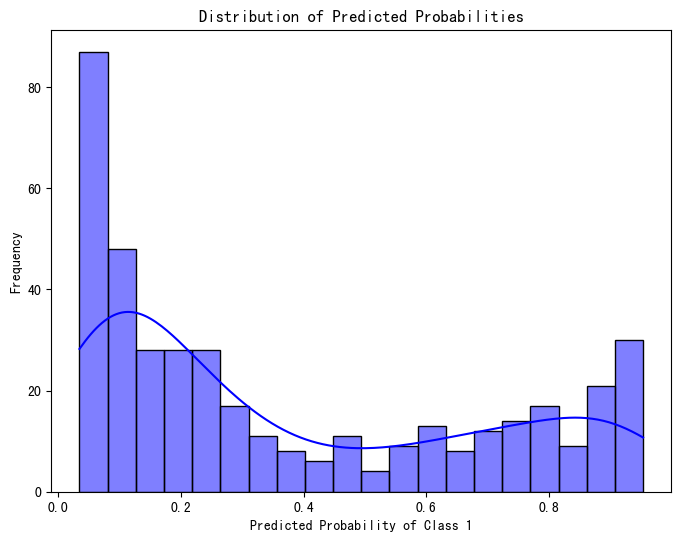

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# 使用Seaborn绘制密度图
plt.figure(figsize=(8, 6))
sns.histplot(df_filtered['predict_y'], kde=True, color='blue', bins=20)
plt.xlabel('Predicted Probability of Class 1')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities')
plt.show()

In [35]:
df_filtered.to_csv('Rweichi.csv', index=False, encoding='utf-8')

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

def vis_cls_of_uplift_bucket(df, f, bucket):
    # 计算每个类别在每个 bucket 中的占比
    category_bucket_counts = df.groupby([f, bucket]).size().unstack(fill_value=0)
    category_proportions = category_bucket_counts.div(category_bucket_counts.sum(axis=1), axis=0)

    # 绘制热力图
    plt.figure(figsize=(10, 6))
#     sns.heatmap(category_proportions, cmap="YlGnBu", linewidths=0.5, annot=True, fmt=".2f")
    sns.heatmap(category_bucket_counts, cmap="YlGnBu", linewidths=0.5, annot=True)
    plt.xlabel('Uplift Bucket')
    plt.ylabel('Category of feature')
    plt.title('Proportion of Category feature in each Uplift Bucket')
    plt.show()

for f in cate_features:
    print('------{%s}------' % f)
    print(labelEncoderDict[f])
    vis_cls_of_uplift_bucket(df_filtered, f, 'bucket')

# 检查每个桶的 uplift 分数范围
for b in sorted(df_filtered['bucket'].unique()):
    print(f"Bucket {b}:")
    print(df_filtered[df_filtered['bucket'] == b]['uplift'].describe())


------{性别（0:女；1:男）}------
{0: 0, 1: 1}


KeyError: 'bucket'

In [37]:
filtered_df = df_filtered[df_filtered['评效分组1']=='2']

# 查看 Rweichi 列分别为 0 和 1 时 pod24 列的分布情况
def get_pod24_distribution(filtered_df):
    distribution = filtered_df.groupby('Rweichi')['pod24'].value_counts().unstack().fillna(0)
    return distribution

distribution = get_pod24_distribution(filtered_df)
print(distribution)


pod24     0   1
Rweichi        
0        44  36
1        25  17


------{LDH（首次治疗）>240是预后不良因素}------


/Users/lixinze/anaconda3/envs/ml/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


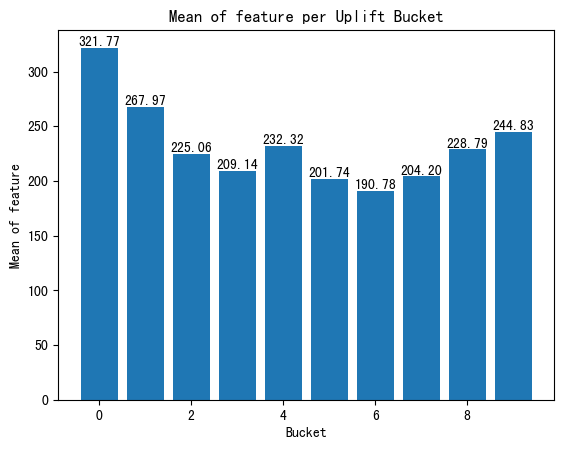

------{治疗时单个淋巴结是否大于6cm（大于6预后不良因素）}------


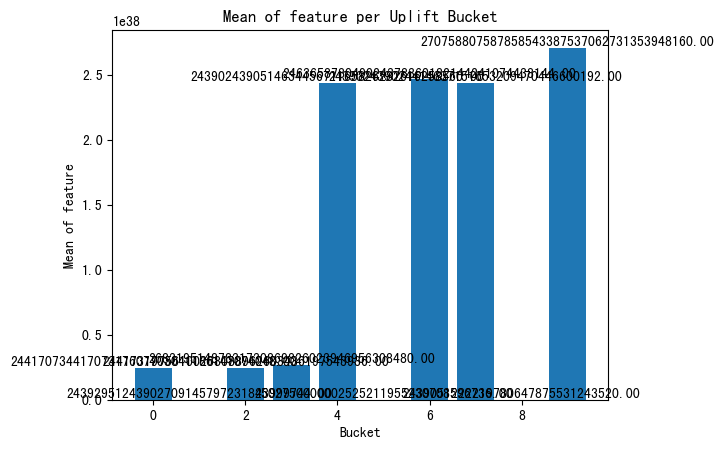

------{β2微球蛋白β2-MG（首次治疗）>3是预后不良因素}------


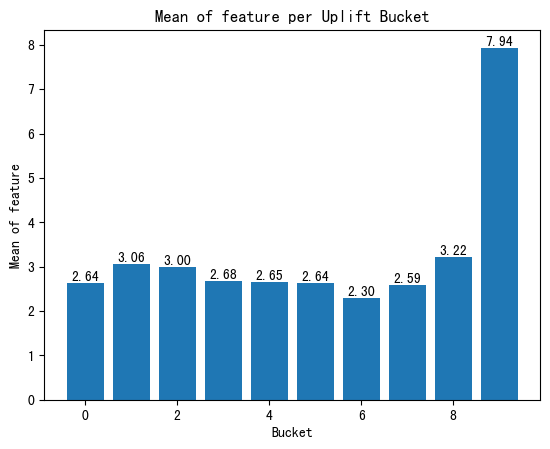

------{最大病灶cm（首次治疗）}------


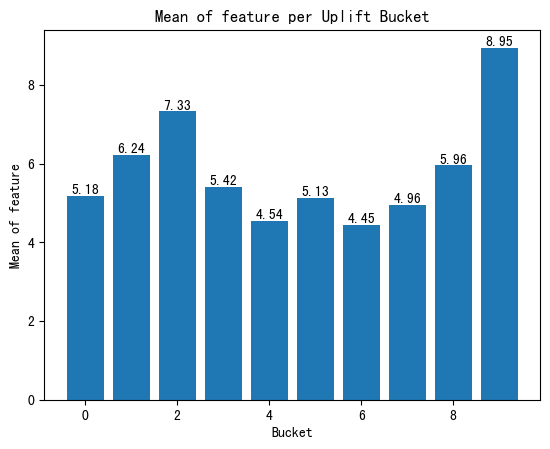

------{启动一线治疗年龄（一般60为cutoff）}------


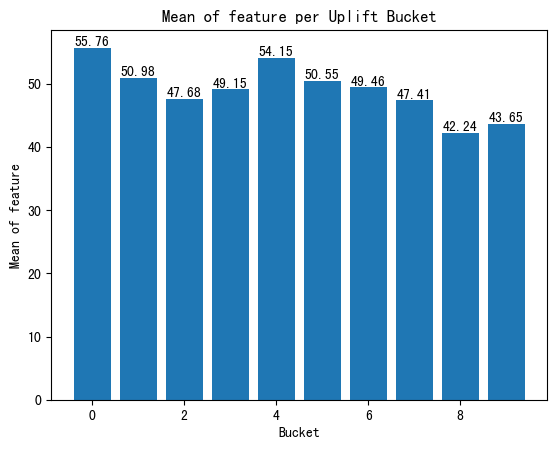

------{淋巴单核细胞比（首次治疗）}------


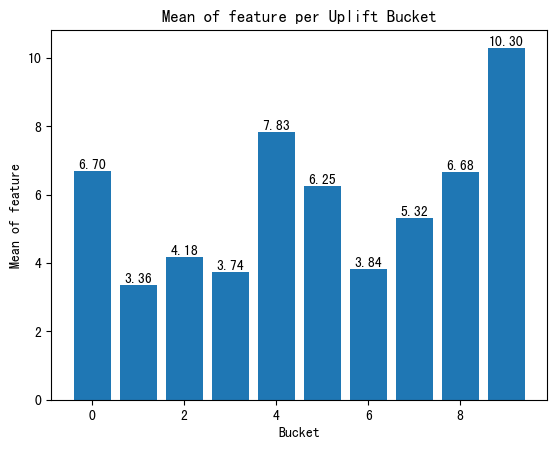

------{SUVmax（首次治疗）}------


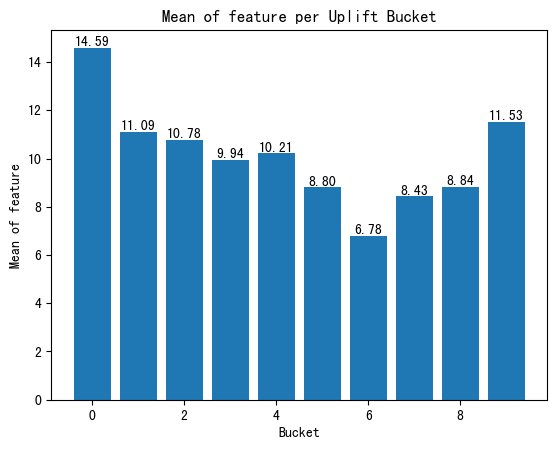

------{PLT（首次治疗）}------


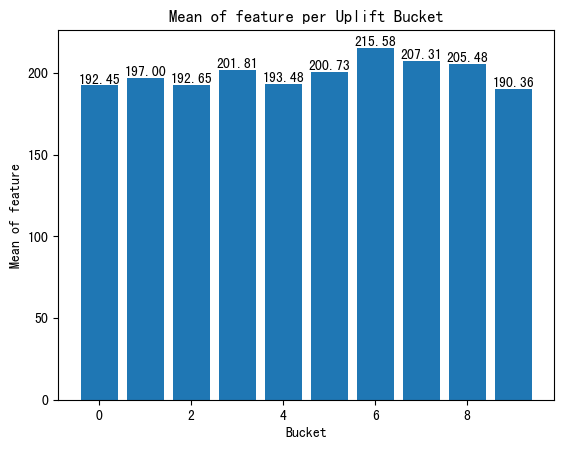

------{一线治疗时累及淋巴结区数目（大于等于5预后不良）}------


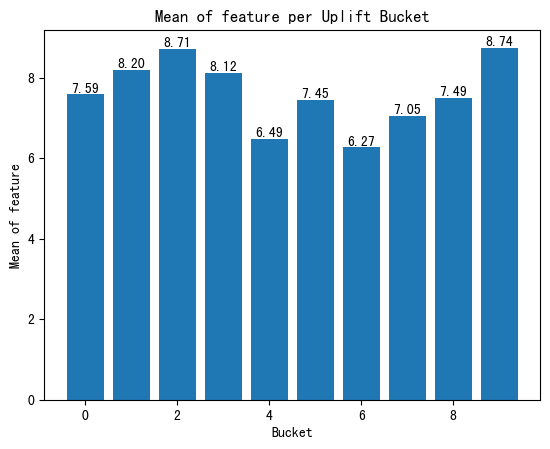

------{治疗时B症状(0:无；1:有)}------


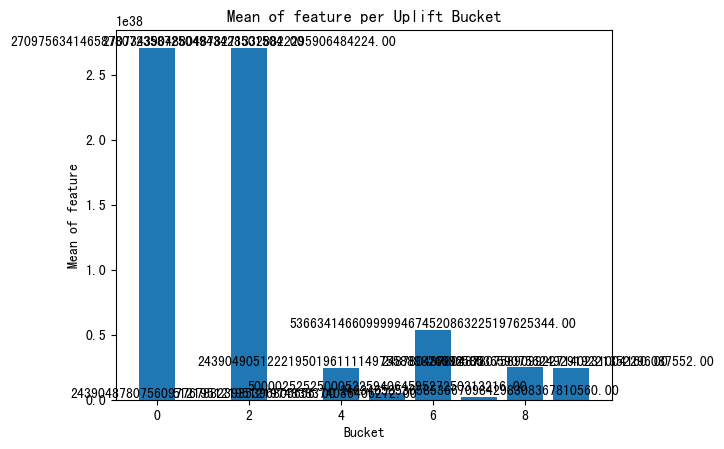

------{单核细胞绝对值（首次治疗）}------


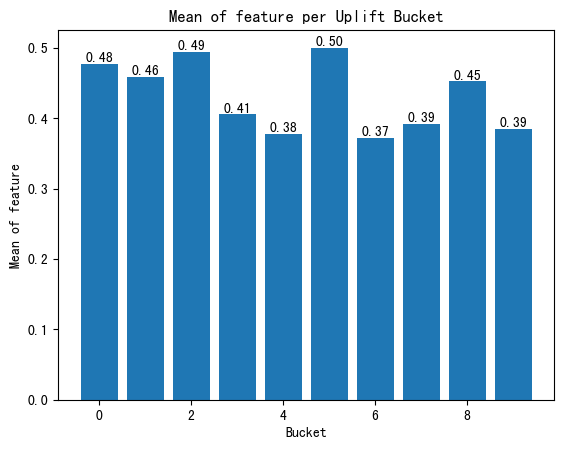

------{HGB（首次治疗）<120是预后不良因素}------


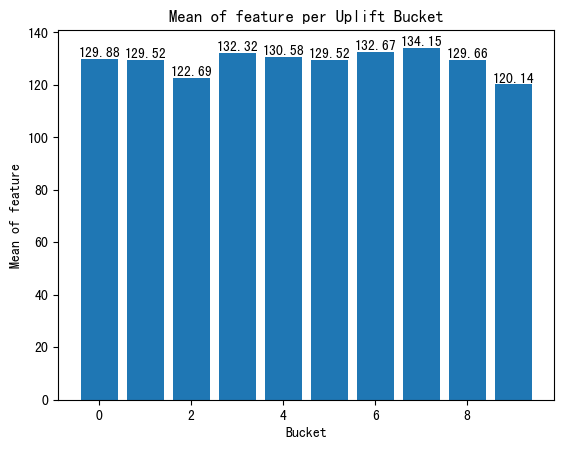

------{WBC（首次治疗）}------


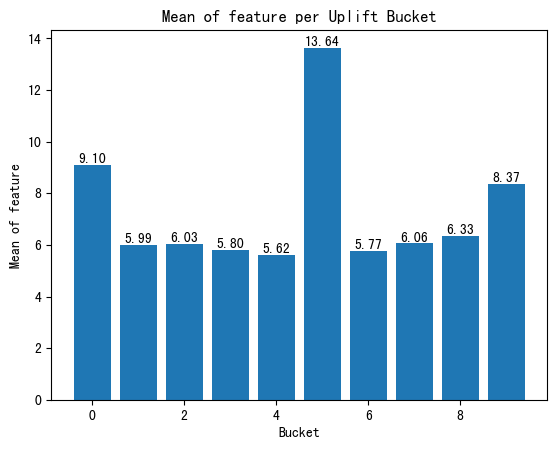

------{治疗时是否骨髓受累（骨髓穿刺明确，有是预后不良因素）}------


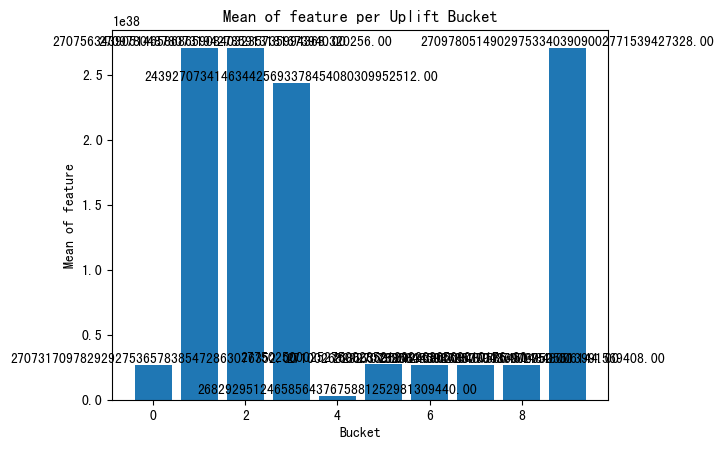

------{淋巴细胞绝对值（首次治疗）}------


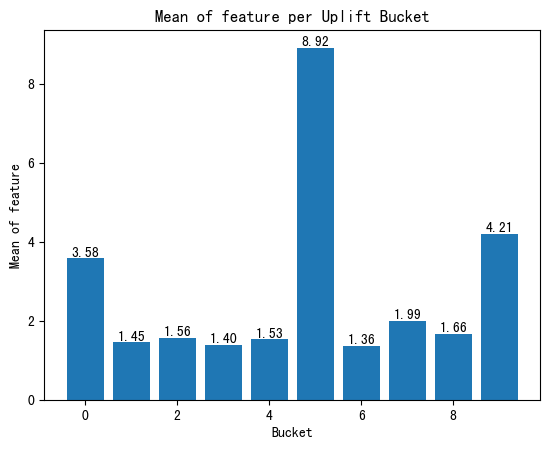

------{治疗时ECOG（体力评分，一般>2是预后不良因素）}------


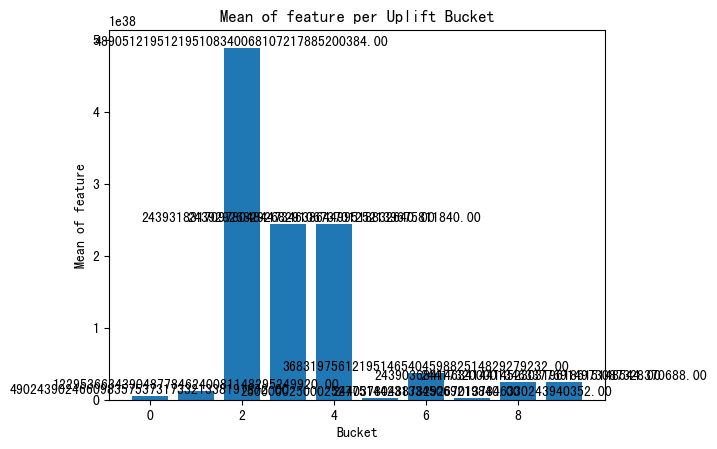

------{评效分组1}------


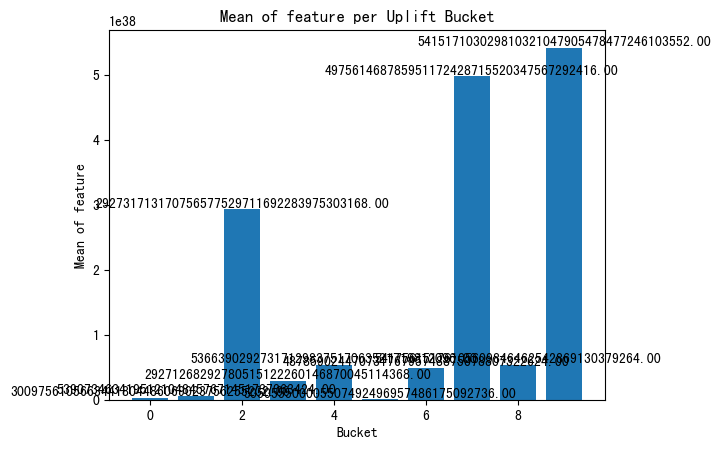

------{性别（0:女；1:男）}------


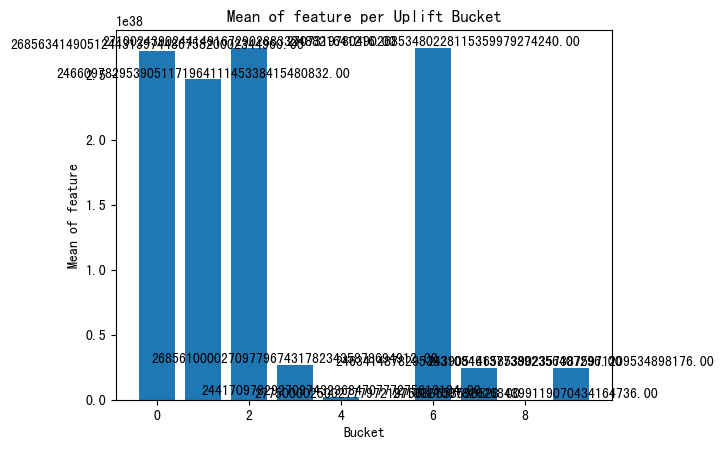

------{首次开始治疗前分期（一般1-2称为局限期，3-4进展期）}------


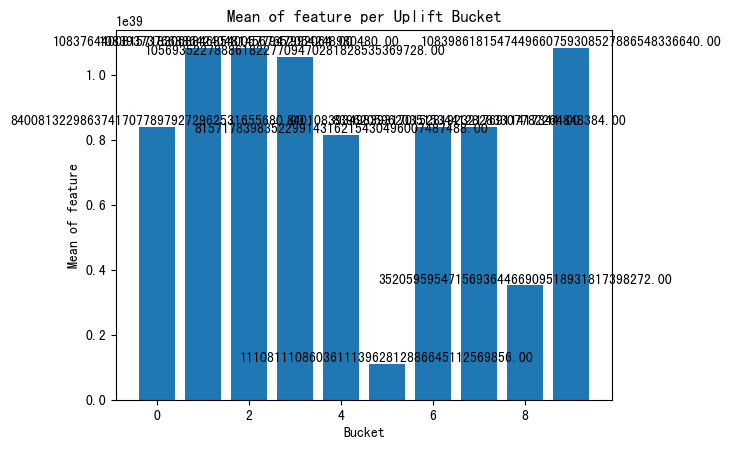

------{启动一线治疗原因（新补充）}------


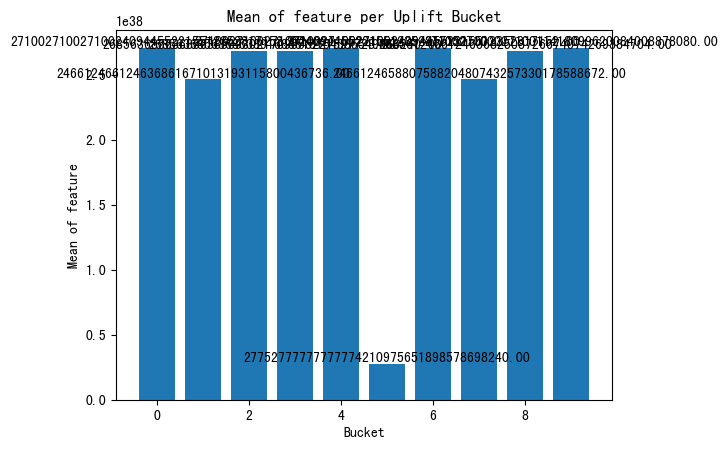

In [38]:


# 将 'uplift' 列的值分成5个桶，并将结果添加到 DataFrame 中
df_filtered['bucket'], bins = pd.qcut(df_filtered['uplift'], q=10, labels=False, retbins=True)

def vis_mean_of_uplift_bucket(df, f, bucket):
    a_mean_per_bucket = df.groupby(bucket)[f].mean()

    plt.bar(a_mean_per_bucket.index, a_mean_per_bucket.values)
    plt.xlabel('Bucket')
    plt.ylabel('Mean of feature')
    plt.title('Mean of feature per Uplift Bucket')

    # 在每个柱子上标注平均值
    for i, v in enumerate(a_mean_per_bucket.values):
        plt.text(i, v, f'{v:.2f}', ha='center', va='bottom')

    plt.show()
import_features_list = DML.get_feature_importance()['feature'].tolist()[:20]
for f in import_features_list:
    print('------{%s}------'%f)
    vis_mean_of_uplift_bucket(df_filtered, f, 'bucket')

In [39]:
def calculate_effective_sample_counts(df, feature, bucket):
    # 计算每个 bucket 中不缺失特征的样本数量
    effective_sample_counts = df.groupby(bucket)[feature].apply(lambda x: x.notnull().sum())
    return effective_sample_counts.tolist()  # 将 Series 转换为列表

# 示例用法
import_features_list = DML.get_feature_importance()['feature'].tolist()[:20]
for f in import_features_list:
    print('------{%s}------'%f)
    effective_sample_counts = calculate_effective_sample_counts(df_filtered, f, 'bucket')
    print(effective_sample_counts)


------{LDH（首次治疗）>240是预后不良因素}------
[35, 33, 36, 36, 37, 39, 41, 40, 39, 35]
------{治疗时单个淋巴结是否大于6cm（大于6预后不良因素）}------
[41, 41, 41, 41, 41, 40, 41, 41, 41, 41]
------{β2微球蛋白β2-MG（首次治疗）>3是预后不良因素}------
[38, 37, 37, 38, 38, 36, 36, 39, 35, 34]
------{最大病灶cm（首次治疗）}------
[39, 39, 40, 36, 36, 33, 30, 33, 35, 39]
------{启动一线治疗年龄（一般60为cutoff）}------
[41, 41, 41, 41, 41, 40, 41, 41, 41, 40]
------{淋巴单核细胞比（首次治疗）}------
[38, 36, 36, 34, 33, 30, 32, 33, 28, 29]
------{SUVmax（首次治疗）}------
[30, 25, 30, 29, 18, 20, 13, 13, 13, 13]
------{PLT（首次治疗）}------
[33, 32, 34, 31, 31, 30, 31, 32, 27, 28]
------{一线治疗时累及淋巴结区数目（大于等于5预后不良）}------
[41, 41, 41, 41, 41, 40, 41, 41, 41, 39]
------{治疗时B症状(0:无；1:有)}------
[41, 41, 41, 41, 41, 40, 41, 41, 41, 41]
------{单核细胞绝对值（首次治疗）}------
[38, 36, 36, 34, 33, 30, 32, 33, 28, 29]
------{HGB（首次治疗）<120是预后不良因素}------
[33, 33, 36, 31, 31, 31, 33, 33, 29, 28]
------{WBC（首次治疗）}------
[33, 32, 34, 31, 31, 30, 31, 32, 27, 28]
------{治疗时是否骨髓受累（骨髓穿刺明确，有是预后不良因素）}------
[41, 41, 41

------{LDH（首次治疗）>240是预后不良因素}------
Effective Sample Counts per Feature Bucket: [38, 39, 35, 37, 37, 37, 37, 37, 37, 37]
Bins: [  96.  143.  156.  170.  183.  202.  217.  238.  269.  313. 1173.]
Counts per Feature Bucket:
 Rweichi          0   1
feature_bucket        
0               20  18
1               21  18
2               19  16
3               21  16
4               28   9
5               27  10
6               25  12
7               17  20
8               23  14
9               27  10


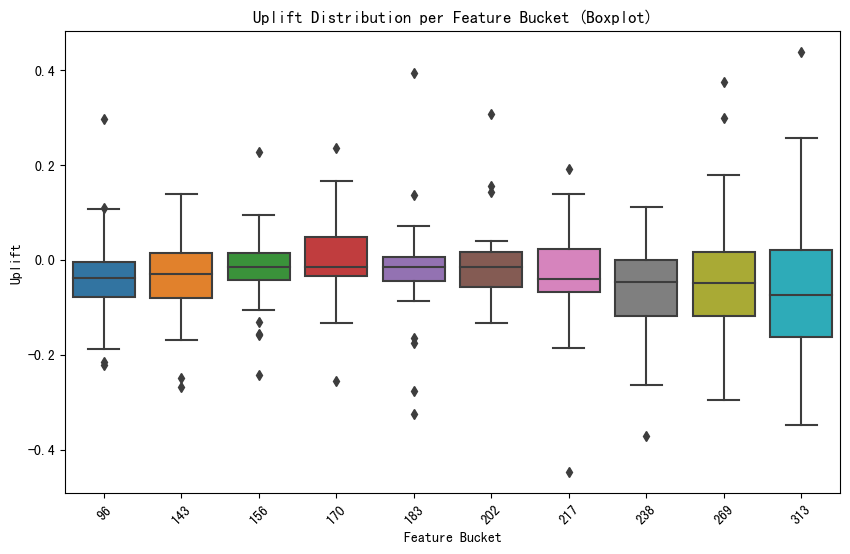

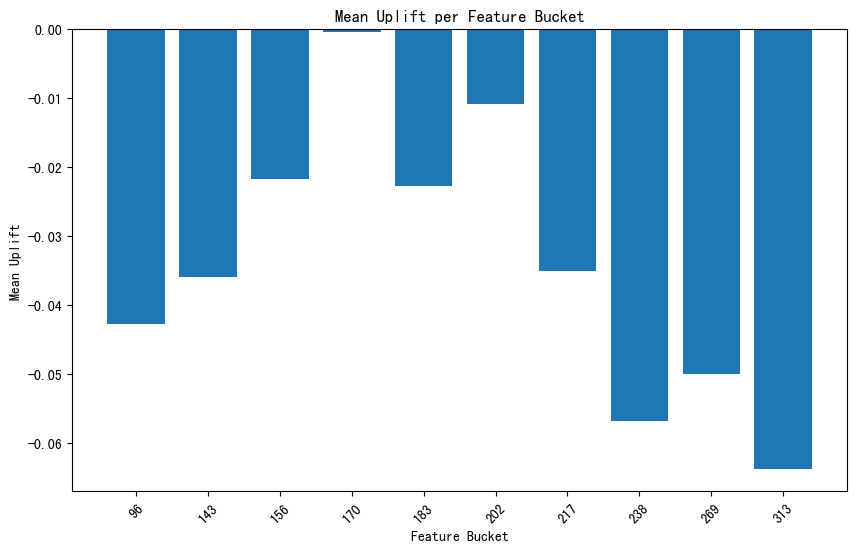

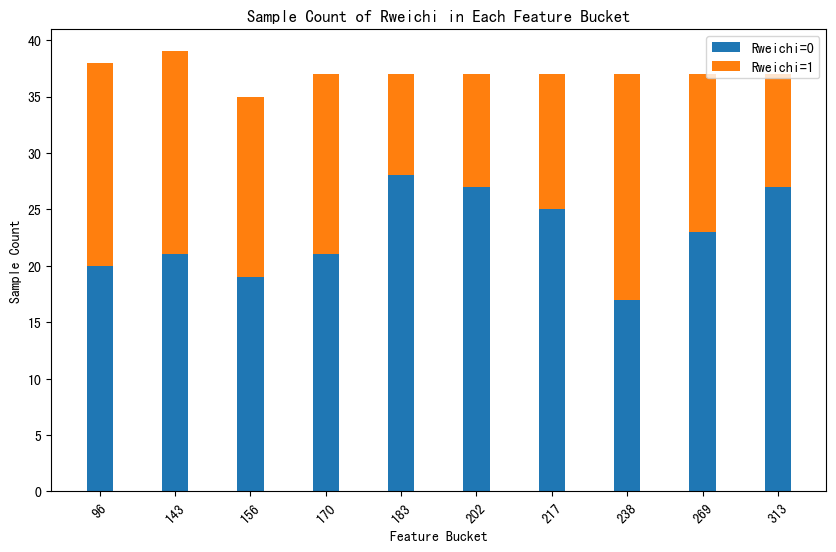

------{β2微球蛋白β2-MG（首次治疗）>3是预后不良因素}------
Effective Sample Counts per Feature Bucket: [37, 37, 38, 36, 36, 37, 36, 37, 37, 37]
Bins: [  0.17    1.447   1.618   1.84    2.11    2.395   2.794   3.549   4.13
   4.886 131.   ]
Counts per Feature Bucket:
 Rweichi          0   1
feature_bucket        
0               18  19
1               23  14
2               22  16
3               19  17
4               24  12
5               24  13
6               24  12
7               21  16
8               26  11
9               21  16


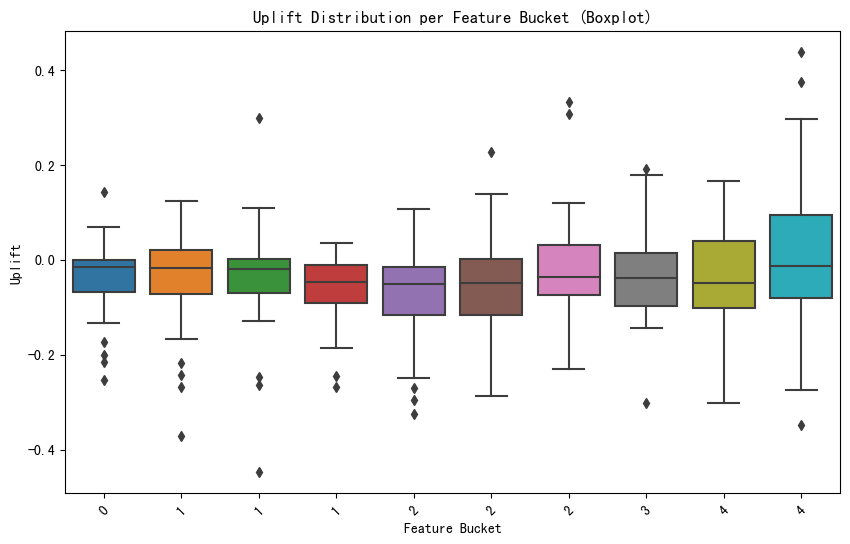

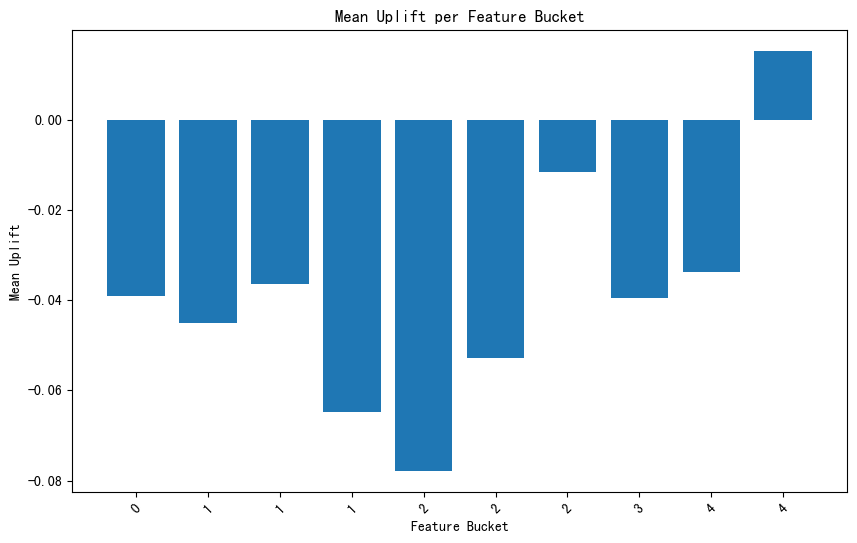

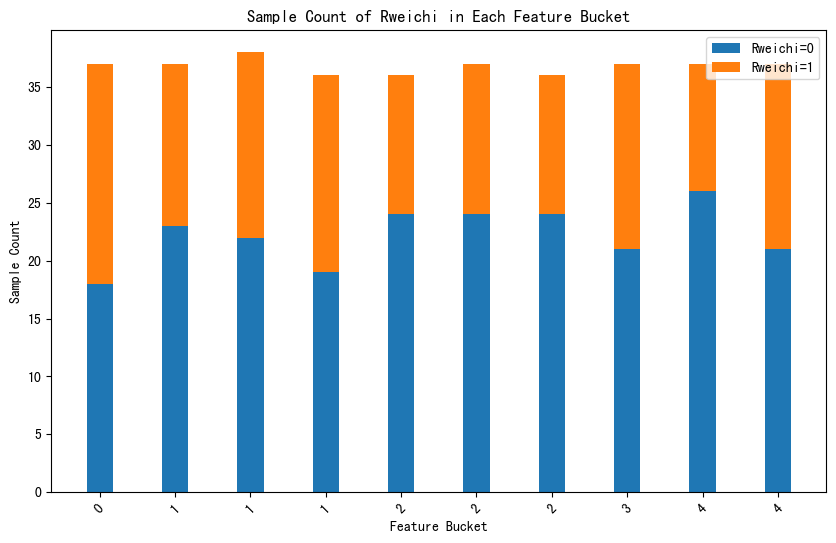

------{最大病灶cm（首次治疗）}------
Effective Sample Counts per Feature Bucket: [37, 36, 37, 34, 40, 33, 35, 39, 33, 36]
Bins: [ 0.8   2.4   3.    3.7   4.36  5.    5.7   6.86  8.2  11.11 18.6 ]
Counts per Feature Bucket:
 Rweichi          0   1
feature_bucket        
0               32   5
1               22  14
2               21  16
3               22  12
4               24  16
5               18  15
6               23  12
7               18  21
8               18  15
9               20  16


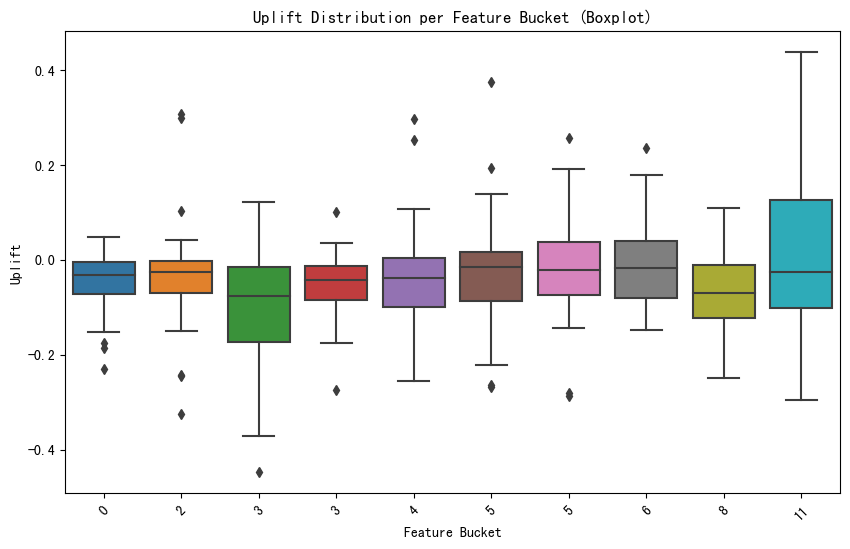

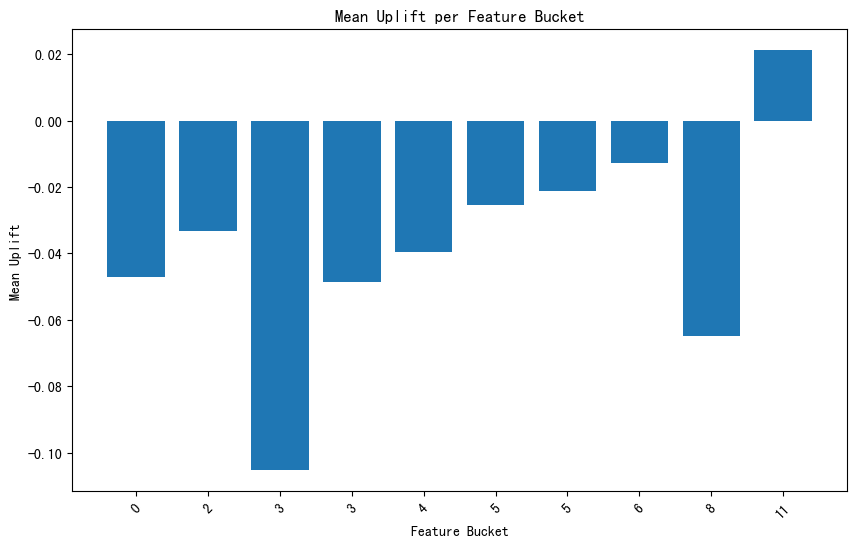

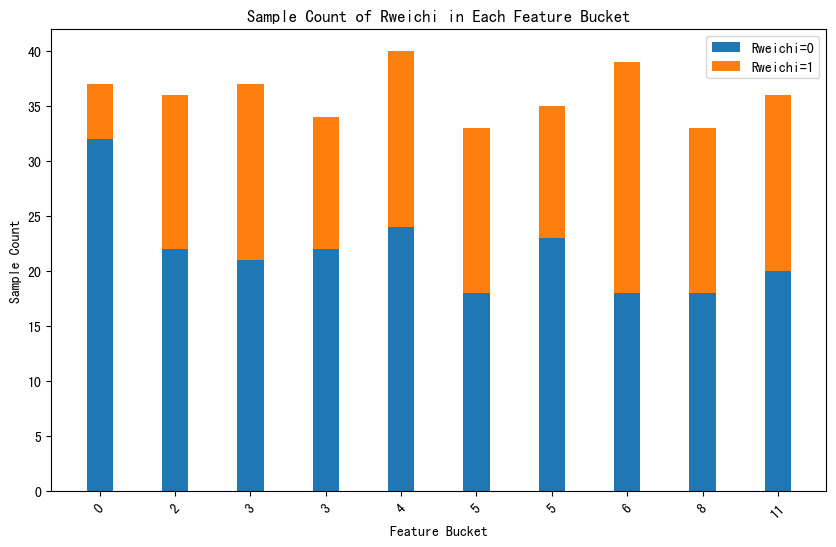

------{启动一线治疗年龄（一般60为cutoff）}------
Effective Sample Counts per Feature Bucket: [46, 38, 49, 31, 44, 39, 50, 29, 44, 38]
Bins: [24.  33.  37.  41.  45.  49.  52.  56.  58.6 65.  86. ]
Counts per Feature Bucket:
 Rweichi          0   1
feature_bucket        
0               27  19
1               17  21
2               32  17
3               14  17
4               26  18
5               25  14
6               27  23
7               15  14
8               36   8
9               30   8


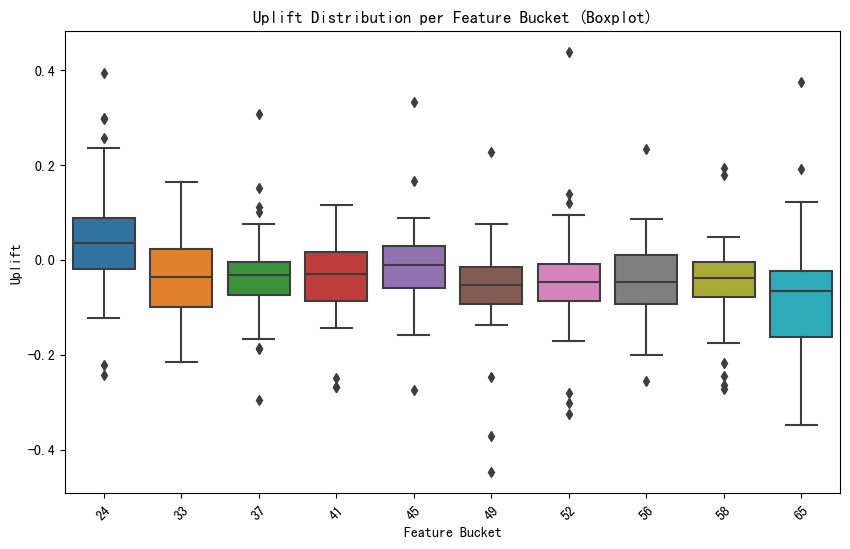

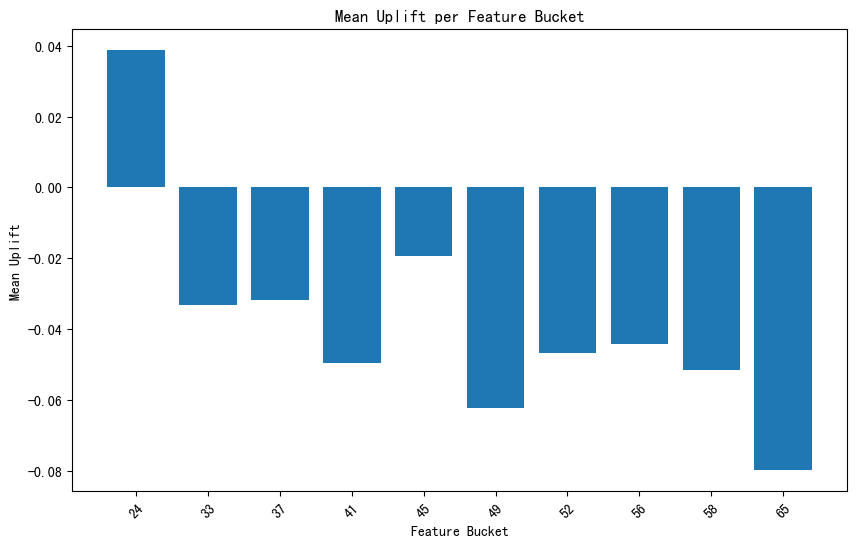

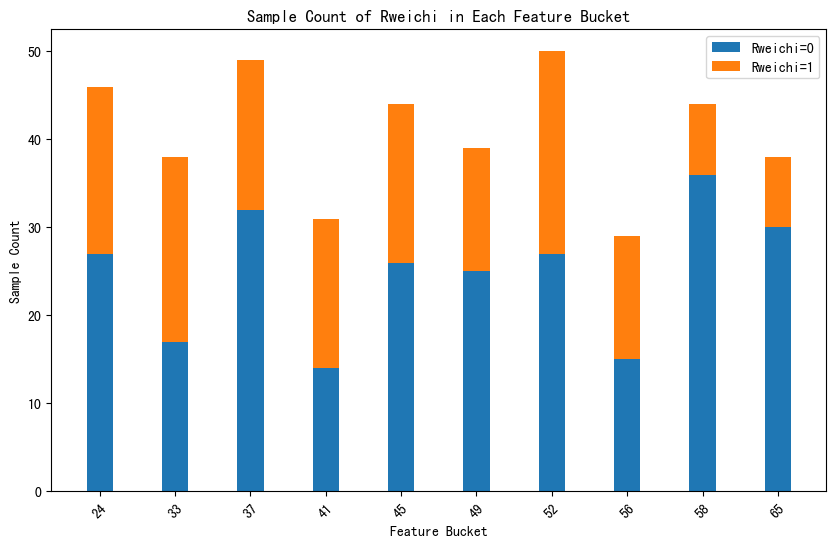

------{淋巴单核细胞比（首次治疗）}------
Effective Sample Counts per Feature Bucket: [33, 33, 33, 33, 33, 32, 33, 33, 33, 33]
Bins: [  0.4          1.69155556   2.25900383   2.64517375   3.06314016
   3.73076923   4.158        5.06736842   6.1721562    7.84333333
 137.66666667]
Counts per Feature Bucket:
 Rweichi          0   1
feature_bucket        
0               26   7
1               22  11
2               21  12
3               23  10
4               19  14
5               21  11
6               17  16
7               11  22
8               16  17
9               20  13


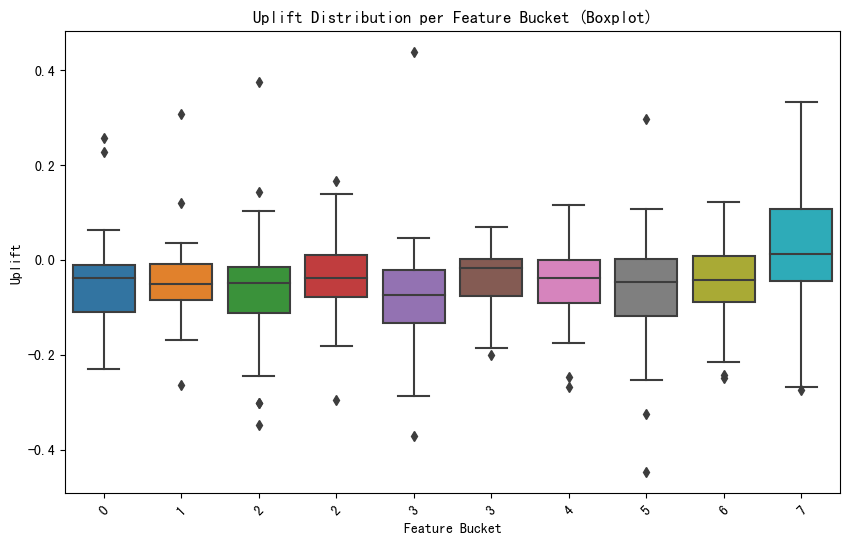

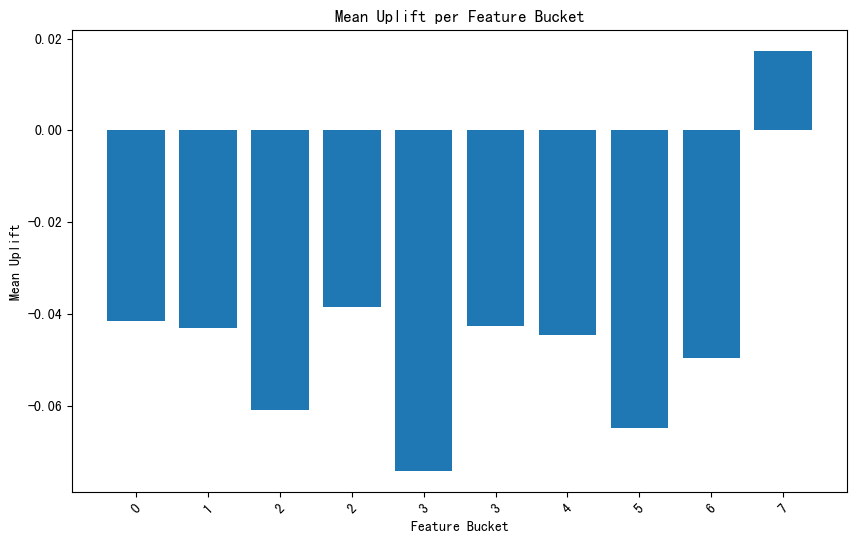

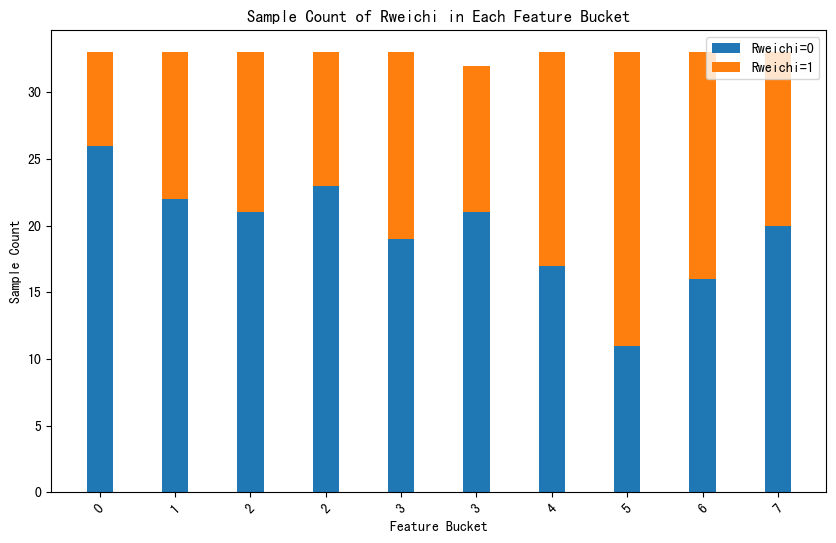

------{SUVmax（首次治疗）}------
Effective Sample Counts per Feature Bucket: [21, 20, 20, 23, 24, 14, 21, 21, 19, 21]
Bins: [ 1.6    4.96   6.792  7.79   8.8    9.8   10.888 11.901 13.9   17.63
 28.2  ]
Counts per Feature Bucket:
 Rweichi          0   1
feature_bucket        
0               15   6
1                8  12
2               13   7
3               12  11
4               16   8
5                7   7
6                9  12
7               14   7
8                8  11
9               14   7


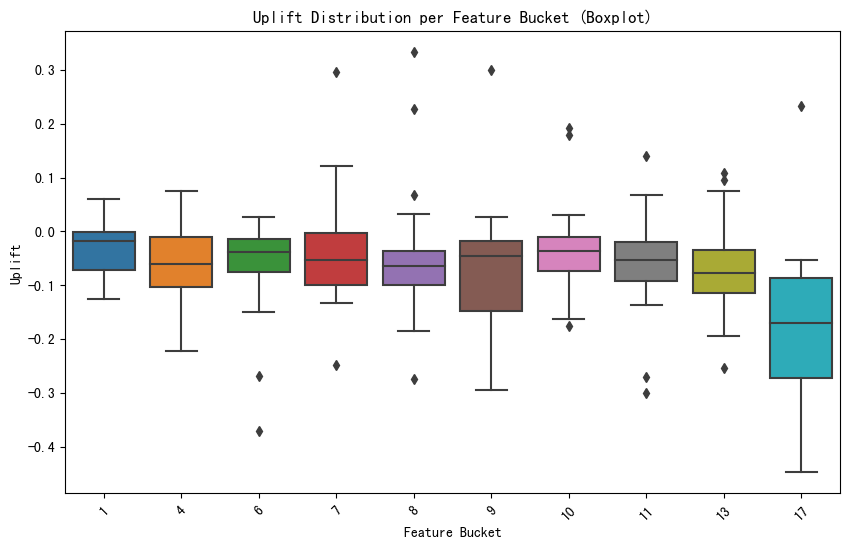

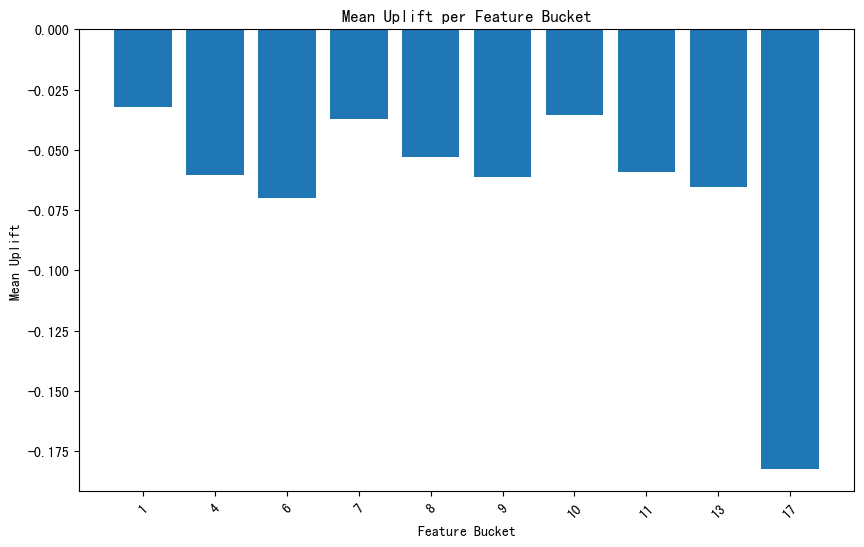

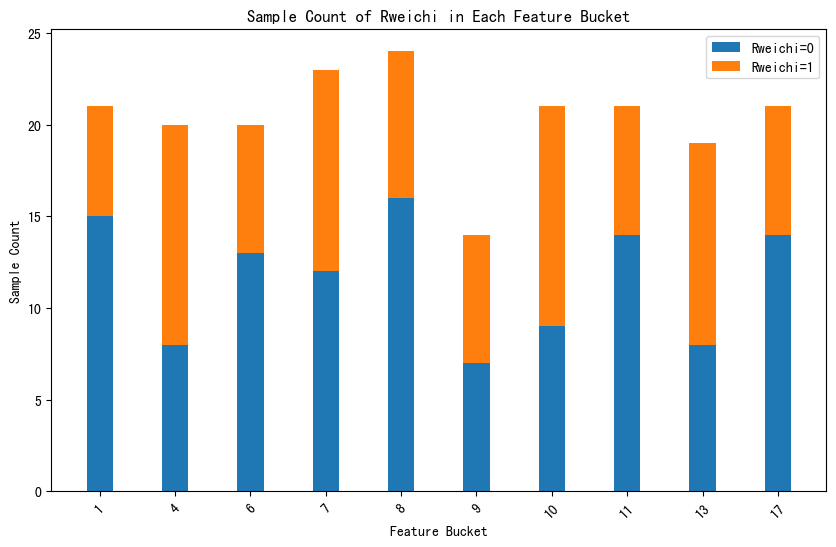

------{PLT（首次治疗）}------
Effective Sample Counts per Feature Bucket: [31, 33, 29, 31, 31, 32, 30, 30, 33, 29]
Bins: [ 22.  125.4 148.  161.4 178.2 195.  213.  228.  246.4 279.  652. ]
Counts per Feature Bucket:
 Rweichi          0   1
feature_bucket        
0               19  12
1               20  13
2               15  14
3               20  11
4               15  16
5               18  14
6               19  11
7               15  15
8               22  11
9               24   5


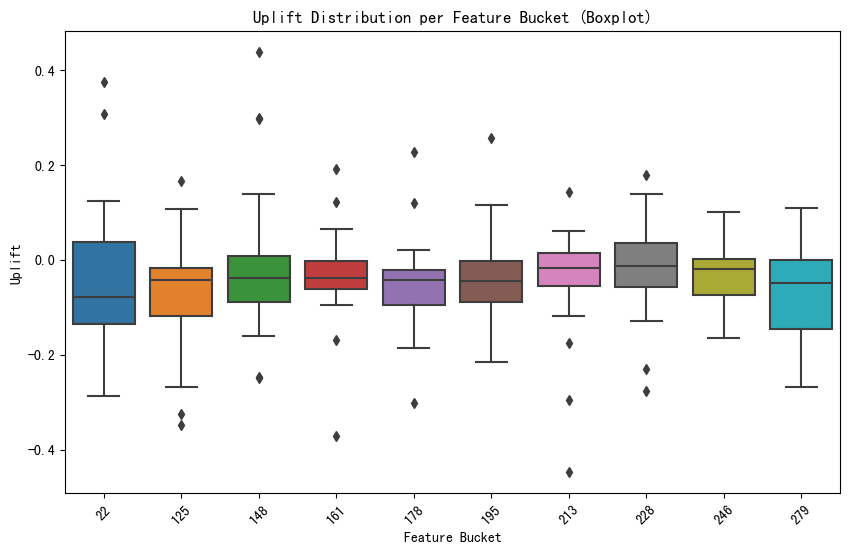

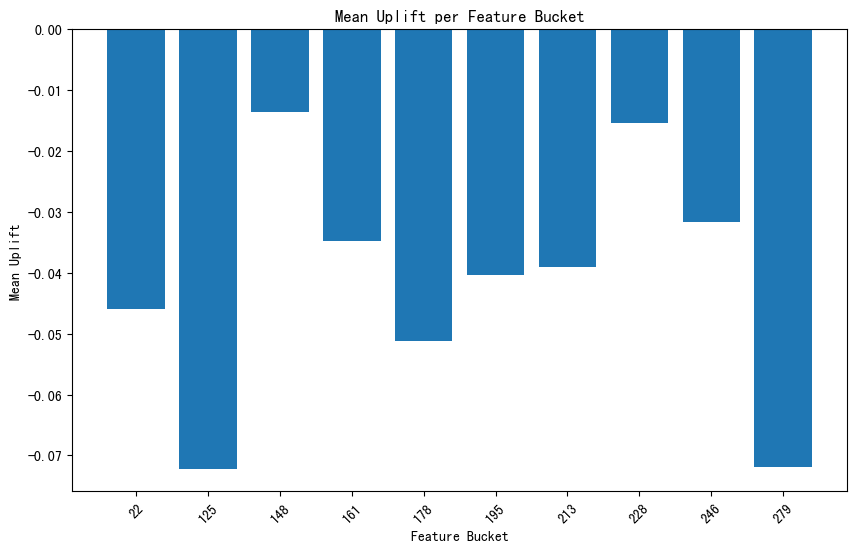

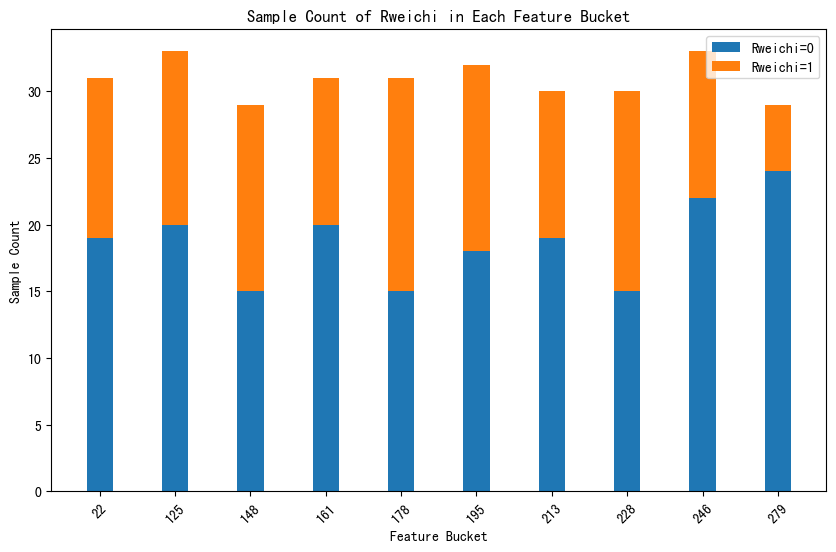

------{一线治疗时累及淋巴结区数目（大于等于5预后不良）}------
Effective Sample Counts per Feature Bucket: [48, 64, 30, 48, 27, 28, 59, 31, 45, 27]
Bins: [ 0.  2.  4.  5.  6.  7.  8. 10. 11. 14. 21.]
Counts per Feature Bucket:
 Rweichi          0   1
feature_bucket        
0               32  16
1               36  28
2               20  10
3               27  21
4               22   5
5               11  17
6               34  25
7               17  14
8               36   9
9               13  14


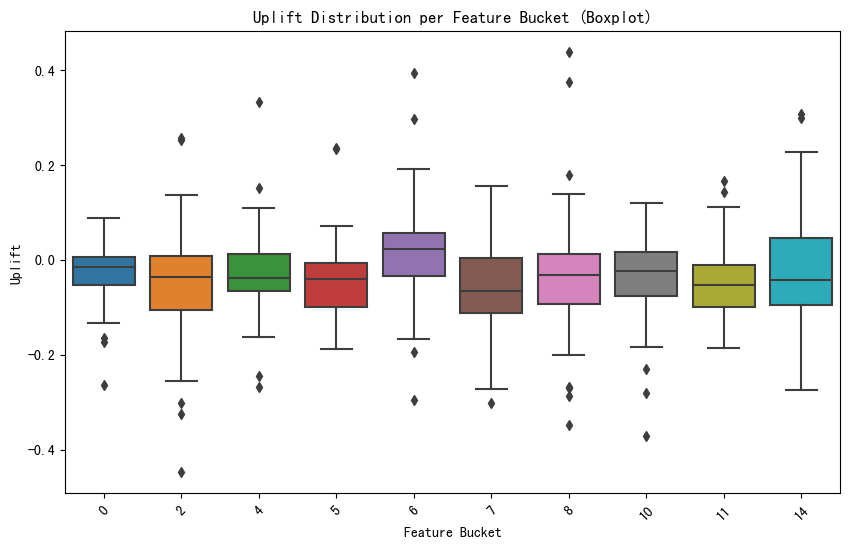

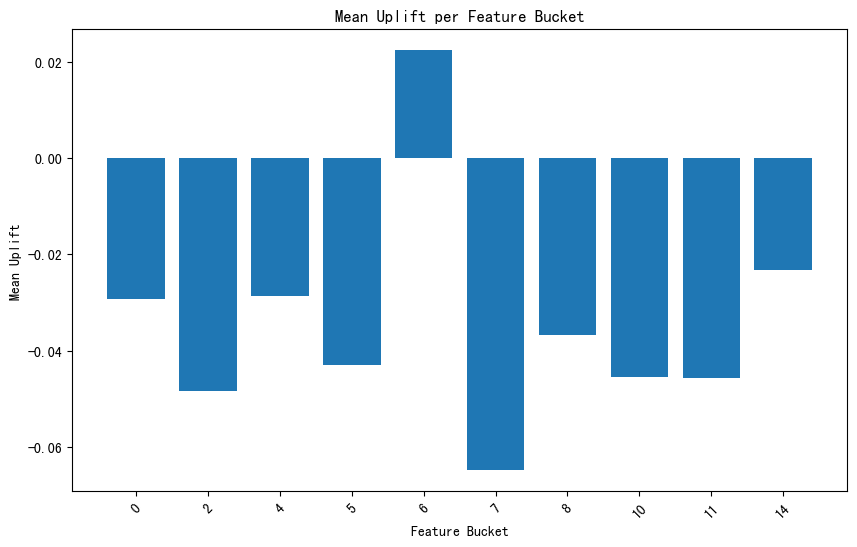

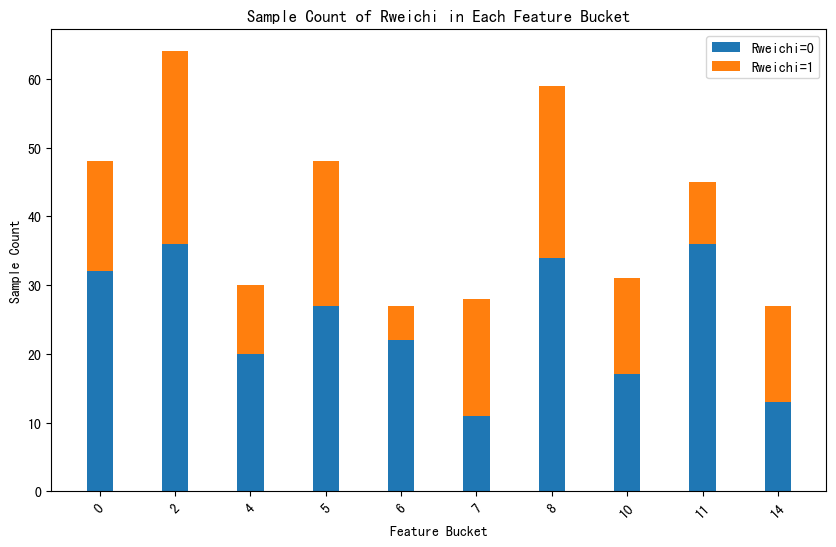

------{单核细胞绝对值（首次治疗）}------
Effective Sample Counts per Feature Bucket: [34, 32, 34, 39, 28, 37, 30, 30, 35, 30]
Bins: [0.01  0.22  0.276 0.31  0.35  0.38  0.43  0.49  0.55  0.64  4.14 ]
Counts per Feature Bucket:
 Rweichi          0   1
feature_bucket        
0               17  17
1               17  15
2               17  17
3               19  20
4               17  11
5               26  11
6               20  10
7               20  10
8               21  14
9               22   8


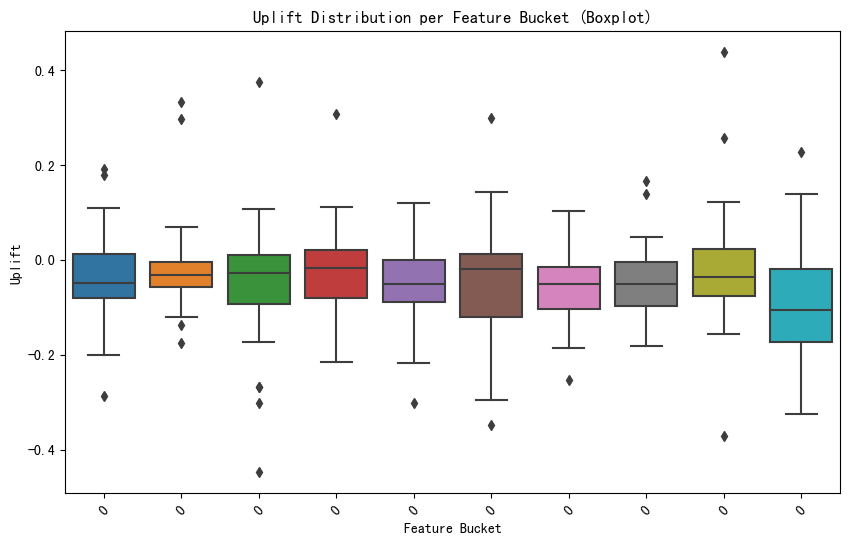

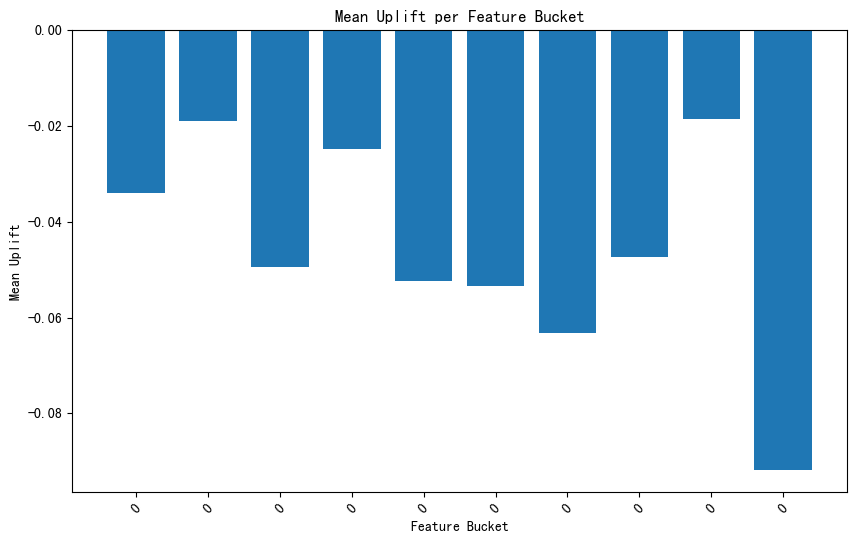

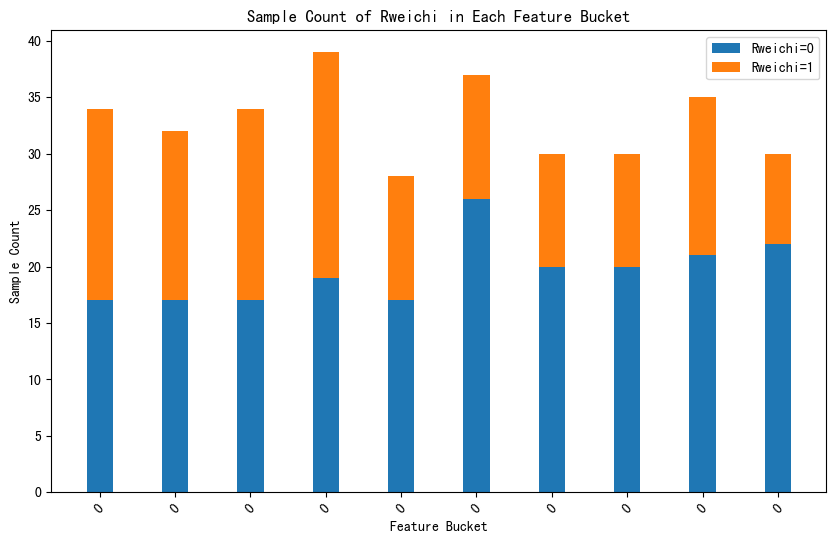

------{HGB（首次治疗）<120是预后不良因素}------
Effective Sample Counts per Feature Bucket: [32, 33, 42, 24, 40, 25, 26, 35, 29, 32]
Bins: [ 66.  109.7 114.  121.  124.  128.  132.  136.9 144.  153.3 172. ]
Counts per Feature Bucket:
 Rweichi          0   1
feature_bucket        
0               19  13
1               24   9
2               30  12
3               11  13
4               23  17
5               16   9
6               12  14
7               21  14
8               16  13
9               20  12


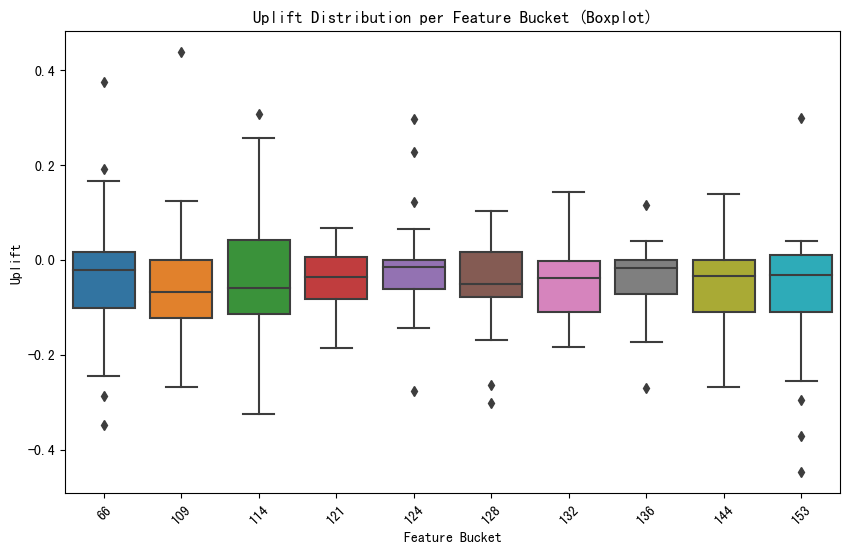

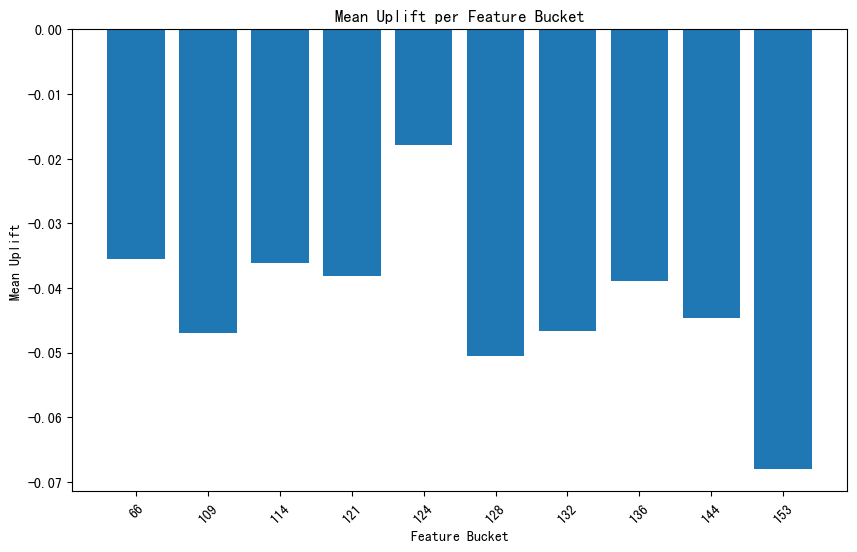

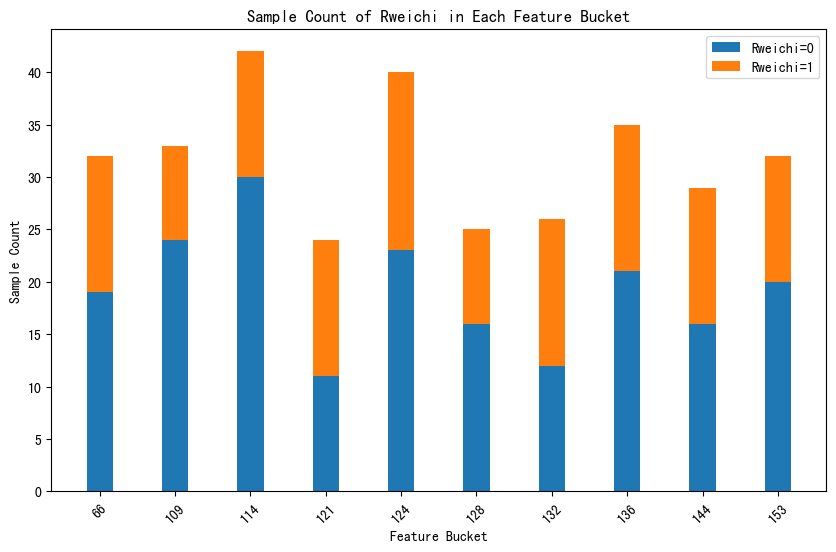

------{WBC（首次治疗）}------
Effective Sample Counts per Feature Bucket: [31, 31, 31, 31, 31, 30, 31, 31, 31, 31]
Bins: [  1.32    3.698   4.336   4.884   5.332   5.9     6.504   7.014   7.768
   9.046 236.83 ]
Counts per Feature Bucket:
 Rweichi          0   1
feature_bucket        
0               19  12
1               12  19
2               19  12
3               18  13
4               21  10
5               16  14
6               19  12
7               21  10
8               24   7
9               18  13


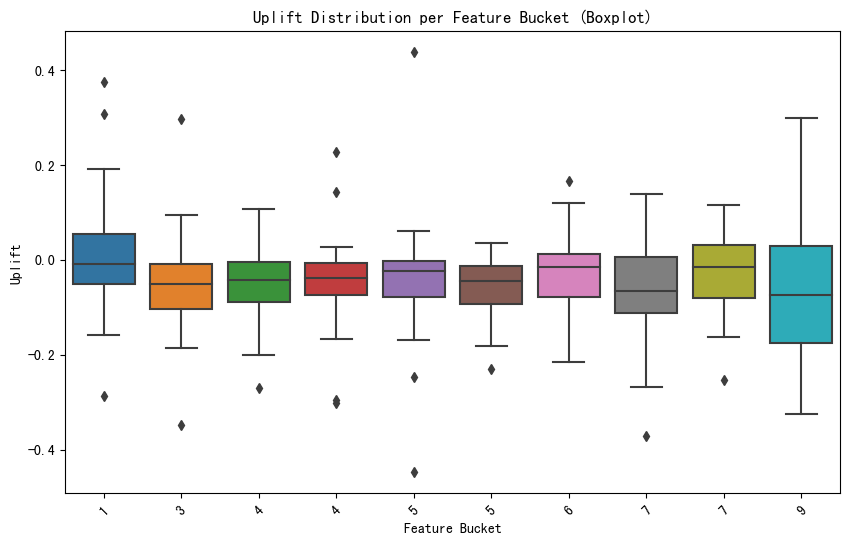

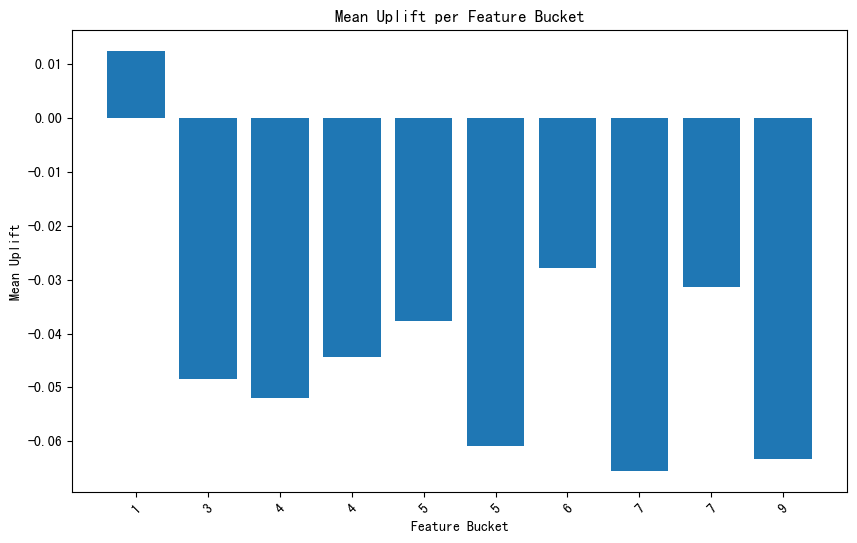

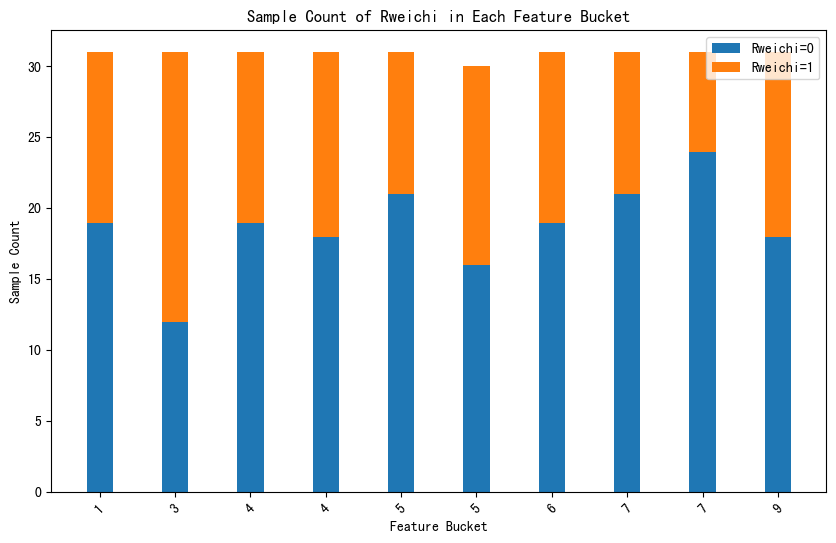

------{淋巴细胞绝对值（首次治疗）}------
Effective Sample Counts per Feature Bucket: [33, 35, 32, 33, 34, 31, 32, 33, 33, 33]
Bins: [1.0000e-01 7.0800e-01 8.5000e-01 1.0400e+00 1.2000e+00 1.3700e+00
 1.5500e+00 1.7580e+00 2.0280e+00 2.9840e+00 2.2626e+02]
Counts per Feature Bucket:
 Rweichi          0   1
feature_bucket        
0               25   8
1               19  16
2               17  15
3               22  11
4               20  14
5               18  13
6               18  14
7               22  11
8               15  18
9               20  13


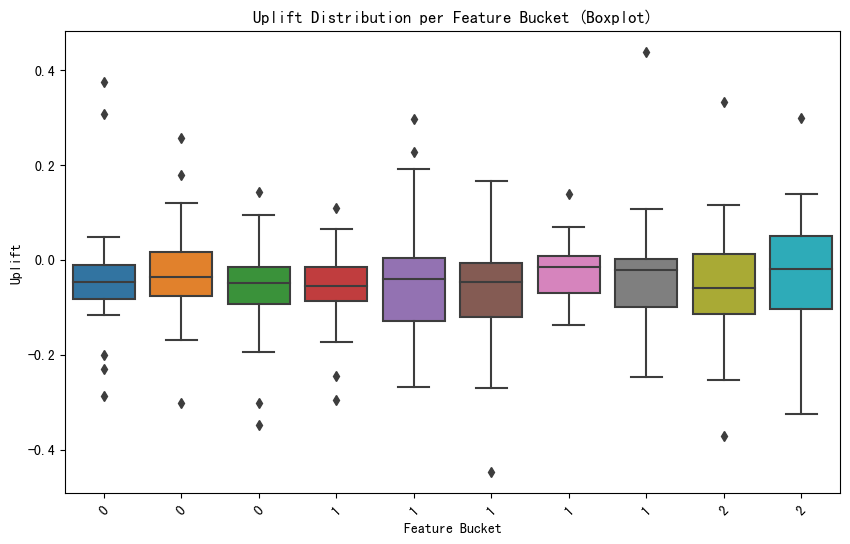

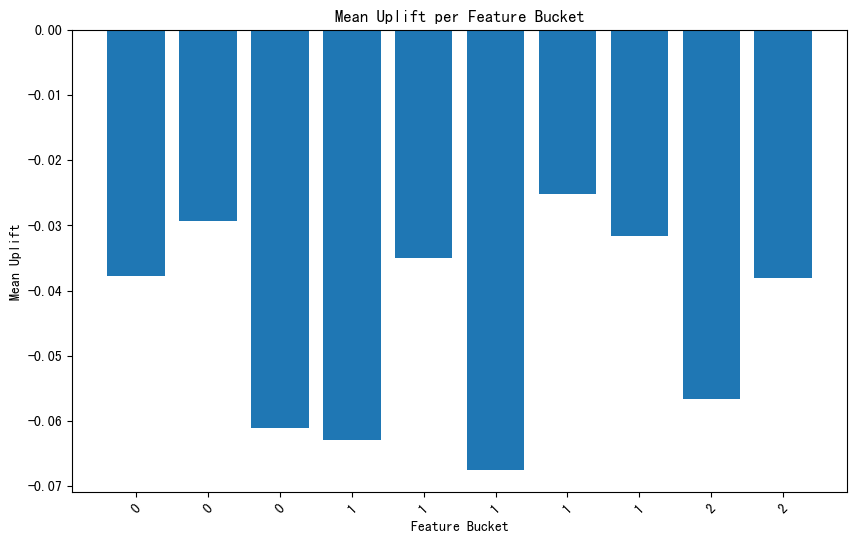

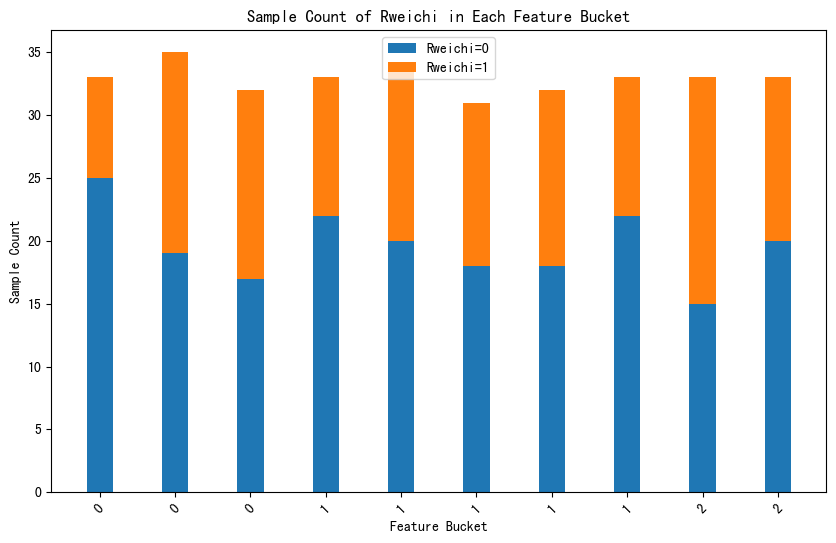

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_effective_sample_counts_and_counts_per_feature_bucket(df, feature, n_bins=10):
    # 使用特征值进行分桶
    df_copy = df.copy()  # 创建副本
    df_copy = df_copy.dropna(subset=[feature])  # 过滤掉含有空值的行
    df_copy['feature_bucket'], bins = pd.qcut(df_copy[feature], q=n_bins, labels=False, retbins=True)
    
    # 计算每个特征值桶内的有效样本数
    effective_sample_counts_per_feature_bucket = df_copy.groupby('feature_bucket').apply(lambda x: x['uplift'].notnull().sum())
    
    # 计算每个特征值桶中 `Rweichi` 列为 0 和 1 的样本个数
    counts_per_feature_bucket = df_copy.groupby('feature_bucket')['Rweichi'].value_counts().unstack().fillna(0)
    
    return effective_sample_counts_per_feature_bucket.tolist(), bins, counts_per_feature_bucket

def vis_boxplot_and_mean_bar_per_feature_bucket(df, feature, n_bins=10):
    # 使用特征值进行分桶
    df_copy = df.copy()  # 创建副本
    df_copy = df_copy.dropna(subset=[feature])  # 过滤掉含有空值的行
    df_copy['feature_bucket'], bins = pd.qcut(df_copy[feature], q=n_bins, labels=False, retbins=True)
    
    # 计算每个特征值桶内 uplift 值的统计信息
    uplift_stats_per_feature_bucket = df_copy.groupby('feature_bucket')['uplift'].describe()
    
    # 计算每个特征值桶内的均值
    mean_uplift_per_feature_bucket = df_copy.groupby('feature_bucket')['uplift'].mean()
    
    # 绘制箱线图
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='feature_bucket', y='uplift', data=df_copy)
    plt.xlabel('Feature Bucket')
    plt.ylabel('Uplift')
    plt.title('Uplift Distribution per Feature Bucket (Boxplot)')
    
    # 设置 x 轴刻度标签为分桶区间
    plt.xticks(range(n_bins), bins[:-1].astype(int), rotation=45)
    
    plt.show()

    # 绘制均值的柱状图
    plt.figure(figsize=(10, 6))
    plt.bar(range(n_bins), mean_uplift_per_feature_bucket.values)
    plt.xlabel('Feature Bucket')
    plt.ylabel('Mean Uplift')
    plt.title('Mean Uplift per Feature Bucket')
    
    # 设置 x 轴刻度标签为分桶区间
    plt.xticks(range(n_bins), bins[:-1].astype(int), rotation=45)
    
    plt.show()

def vis_counts_per_feature_bucket(counts, bins, n_bins=10):
    # 绘制 Rweichi 列的样本个数柱状图
    plt.figure(figsize=(10, 6))
    
    bar_width = 0.35
    index = range(n_bins)
    
    plt.bar(index, counts[0], bar_width, label='Rweichi=0')
    plt.bar(index, counts[1], bar_width, bottom=counts[0], label='Rweichi=1')
    
    plt.xlabel('Feature Bucket')
    plt.ylabel('Sample Count')
    plt.title('Sample Count of Rweichi in Each Feature Bucket')
    
    # 设置 x 轴刻度标签为分桶区间
    plt.xticks(range(n_bins), bins[:-1].astype(int), rotation=45)
    plt.legend()
    
    plt.show()

# 示例用法
import_features_list = DML.get_feature_importance()['feature'].tolist()[:20]
for f in import_features_list:
    if f in cate_features:
        continue
    print('------{%s}------' % f)
    effective_sample_counts_per_feature_bucket, bins, counts = calculate_effective_sample_counts_and_counts_per_feature_bucket(df_filtered, f)
    print("Effective Sample Counts per Feature Bucket:", effective_sample_counts_per_feature_bucket)
    print("Bins:", bins)
    print("Counts per Feature Bucket:\n", counts)
    vis_boxplot_and_mean_bar_per_feature_bucket(df_filtered, f)
    vis_counts_per_feature_bucket(counts, bins)


In [41]:
filtered_df = df_filtered[df_filtered['β2微球蛋白β2-MG（首次治疗）>3是预后不良因素'] > 4.9]

# 查看 Rweichi 列分别为 0 和 1 时 pod24 列的分布情况
def get_pod24_distribution(filtered_df):
    distribution = filtered_df.groupby('Rweichi')['pod24'].value_counts().unstack().fillna(0)
    return distribution

distribution = get_pod24_distribution(filtered_df)
print(distribution)


pod24    0   1
Rweichi       
0        7  10
1        8   6


In [42]:
filtered_df = df_filtered[df_filtered['最大病灶cm（首次治疗）'] > 12]

distribution = get_pod24_distribution(filtered_df)
print(distribution)


pod24    0  1
Rweichi      
0        7  6
1        8  4


In [43]:
filtered_df = df_filtered[pd.isna(df_filtered['SUVmax（首次治疗）'])]
distribution = get_pod24_distribution(filtered_df)
print(distribution)

pod24     0   1
Rweichi        
0        76  57
1        52  20


------{LDH（首次治疗）>240是预后不良因素}------


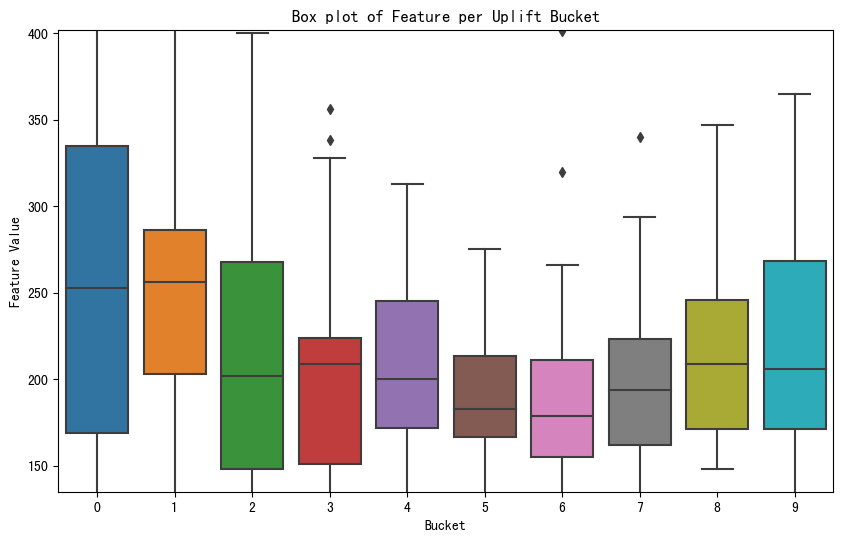

------{β2微球蛋白β2-MG（首次治疗）>3是预后不良因素}------


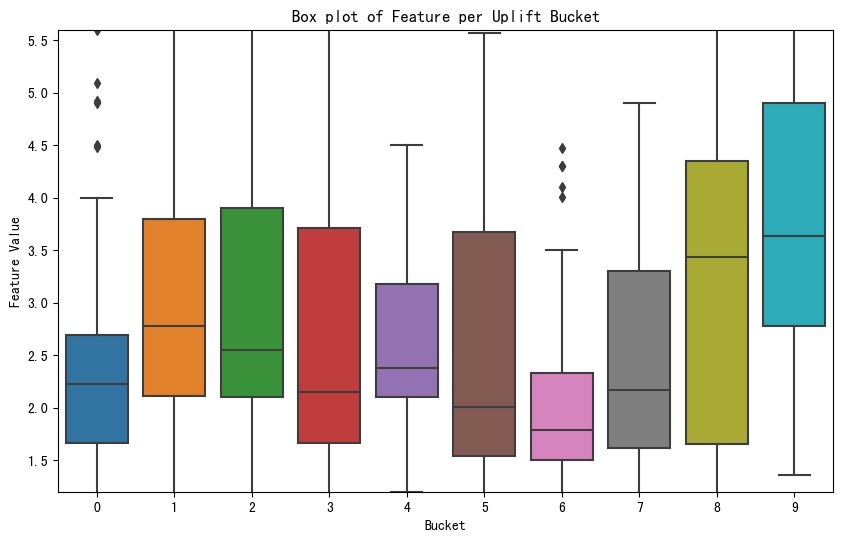

------{最大病灶cm（首次治疗）}------


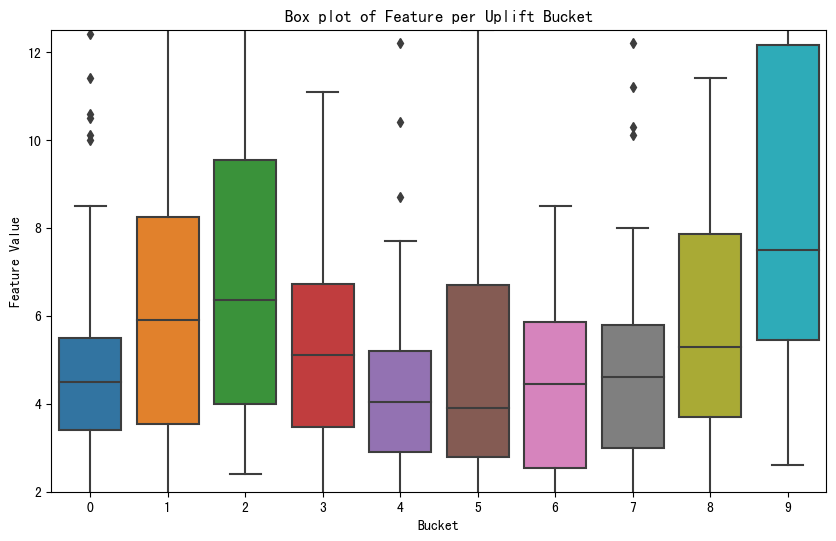

------{启动一线治疗年龄（一般60为cutoff）}------


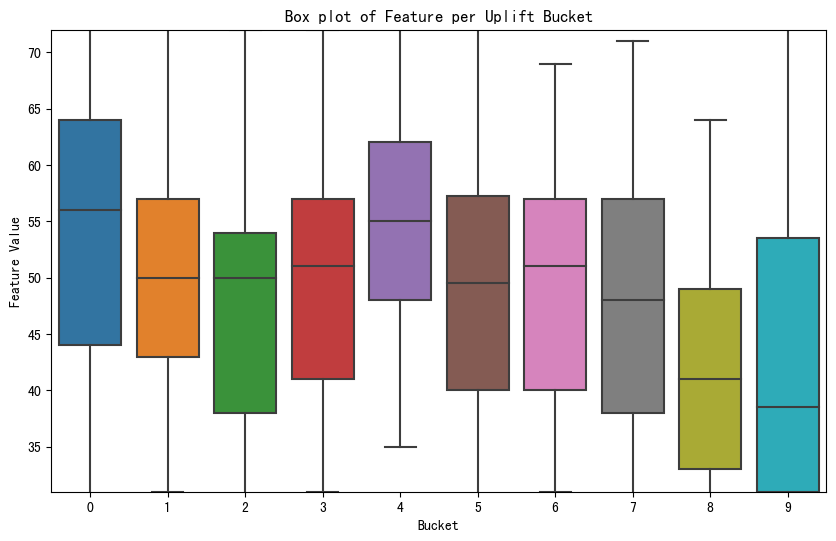

------{淋巴单核细胞比（首次治疗）}------


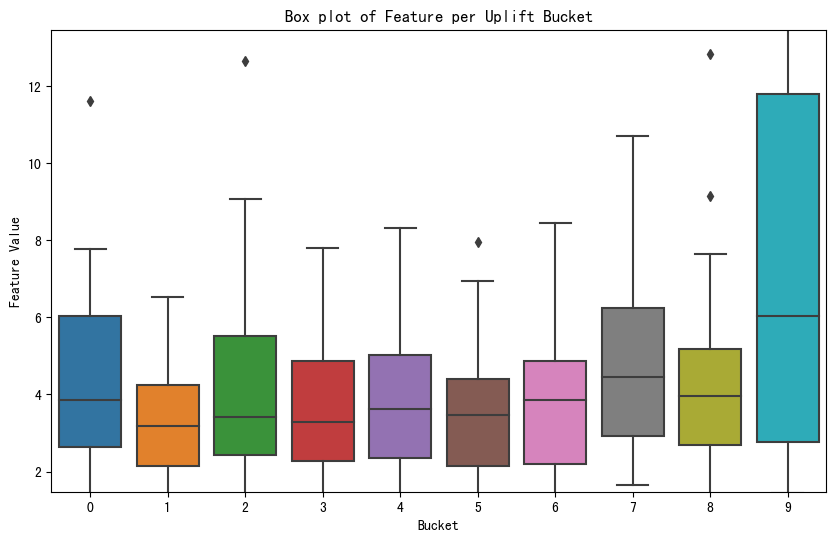

------{SUVmax（首次治疗）}------


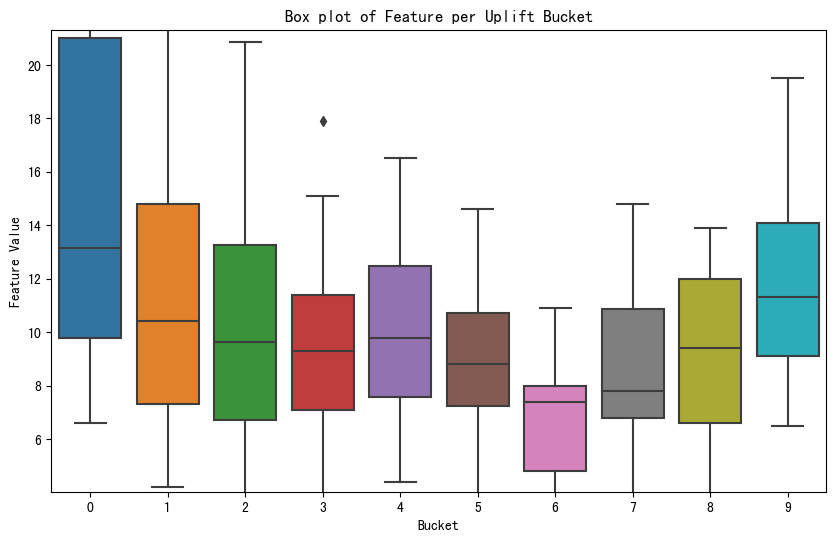

------{PLT（首次治疗）}------


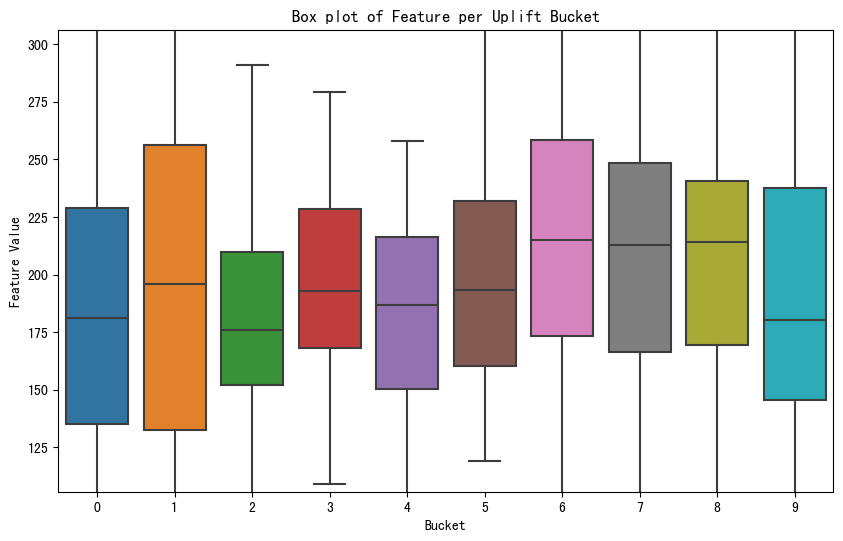

------{一线治疗时累及淋巴结区数目（大于等于5预后不良）}------


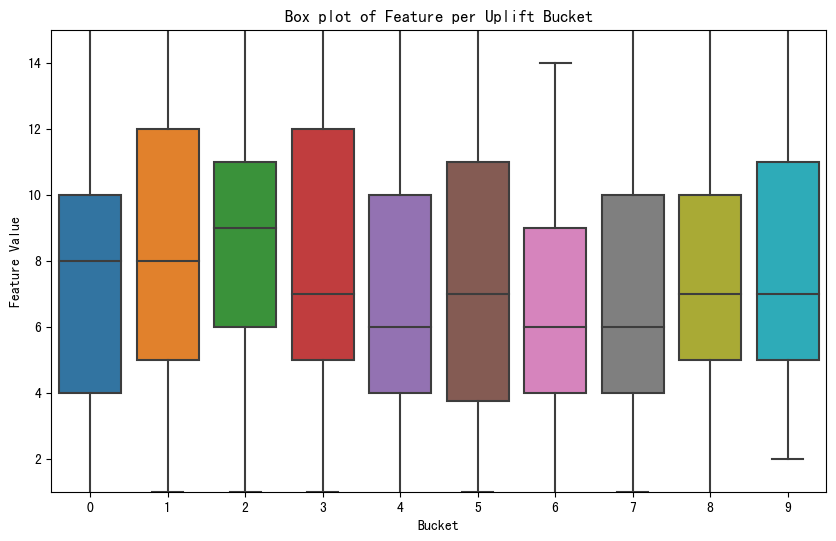

------{单核细胞绝对值（首次治疗）}------


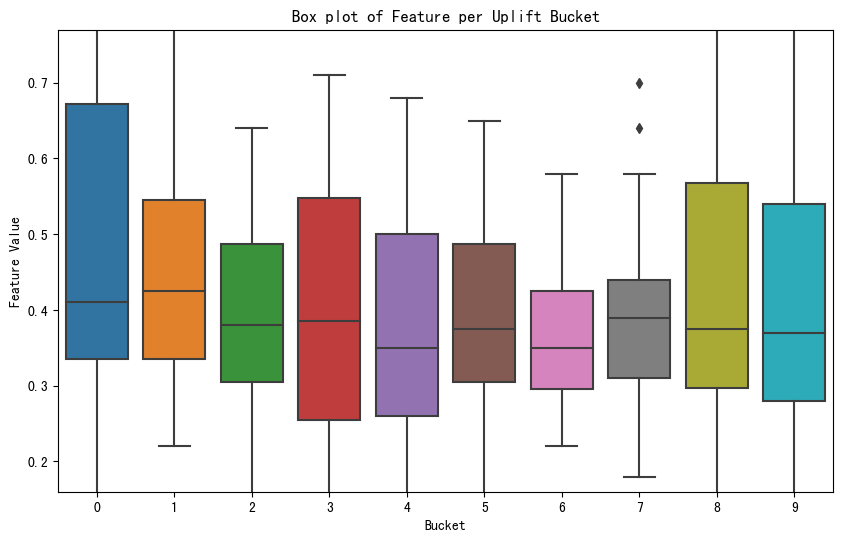

------{HGB（首次治疗）<120是预后不良因素}------


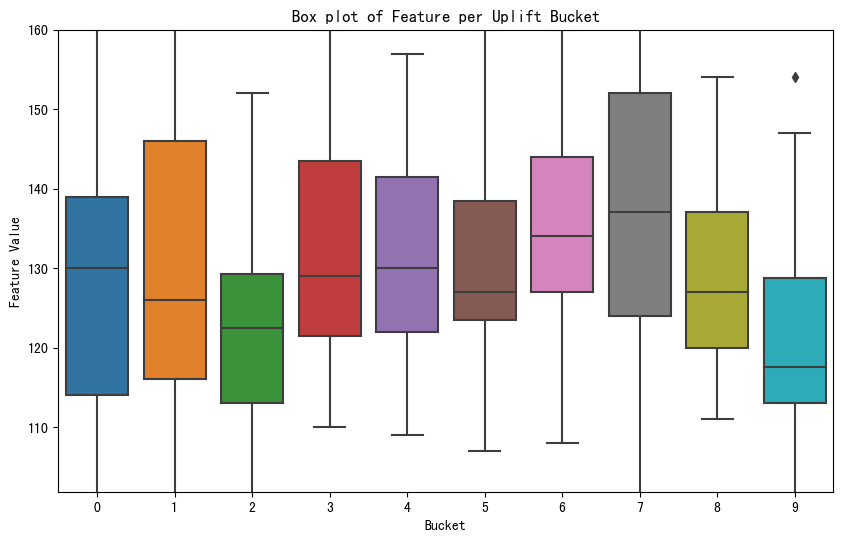

------{WBC（首次治疗）}------


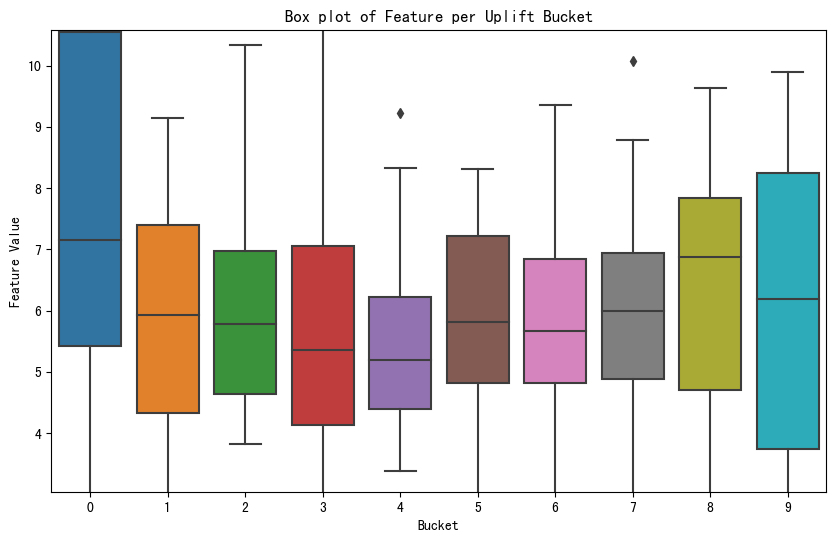

------{淋巴细胞绝对值（首次治疗）}------


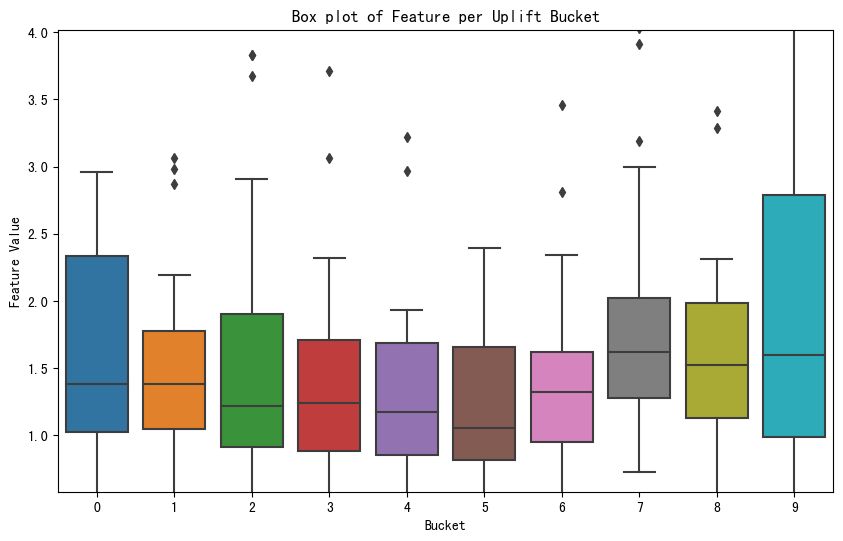

In [44]:
def vis_boxplot_of_uplift_bucket(df, f, bucket):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=bucket, y=f, data=df)
    plt.ylim(df[f].quantile(0.05), df[f].quantile(0.95))  # 限制 y 轴范围为数据的 5% 和 95% 分位数
    plt.xlabel('Bucket')
    plt.ylabel('Feature Value')
    plt.title('Box plot of Feature per Uplift Bucket')
    plt.show()

# 示例用法
import_features_list = DML.get_feature_importance()['feature'].tolist()[:20]
for f in import_features_list:
    if f in cate_features:
        continue
    print('------{%s}------'%f)
    vis_boxplot_of_uplift_bucket(df_filtered, f, 'bucket')


In [45]:
print(bins)
df_filtered['bucket']

[1.0000e-01 7.0800e-01 8.5000e-01 1.0400e+00 1.2000e+00 1.3700e+00
 1.5500e+00 1.7580e+00 2.0280e+00 2.9840e+00 2.2626e+02]


0      8
1      9
2      2
3      4
4      4
      ..
438    1
439    8
440    9
441    4
442    2
Name: bucket, Length: 409, dtype: int64

------{性别（0:女；1:男）}------
{0: 0, 1: 1}


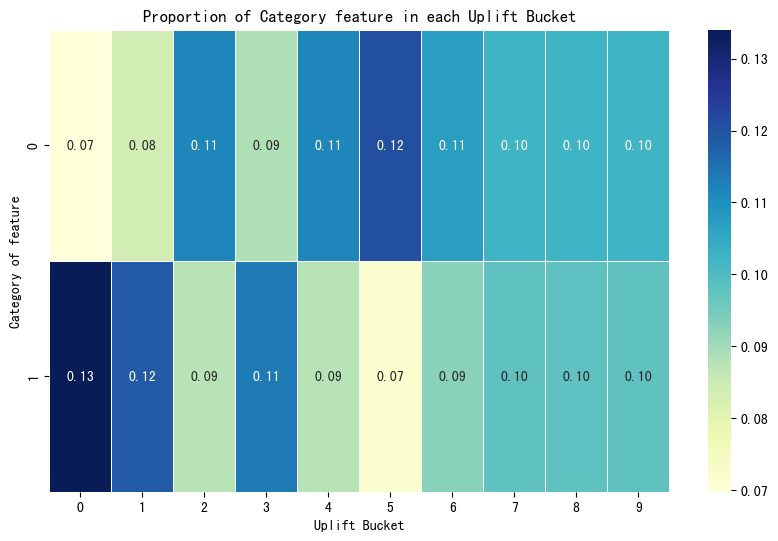

------{一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）}------
{'1-2级': 0, '1-2级，局灶3a级': 1, '3a级': 2, '3a级，可能有转化': 3, '3b级': 4, '3级': 5, '3级 ': 6, 'TFL,DLBCL': 7, 'tFL,DLBCL': 8, nan: 9}


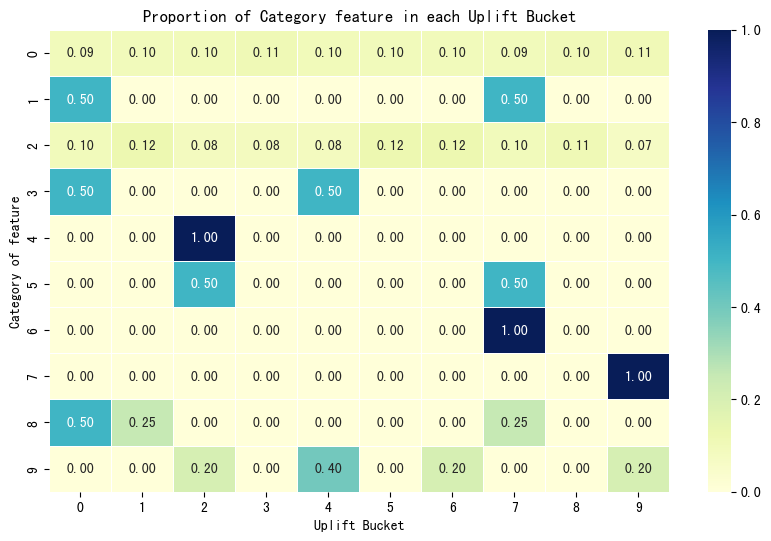

------{治疗时ECOG（体力评分，一般>2是预后不良因素）}------
{0.0: 0, 1.0: 1, 2.0: 2, 3.0: 3, 4.0: 4, nan: 5}


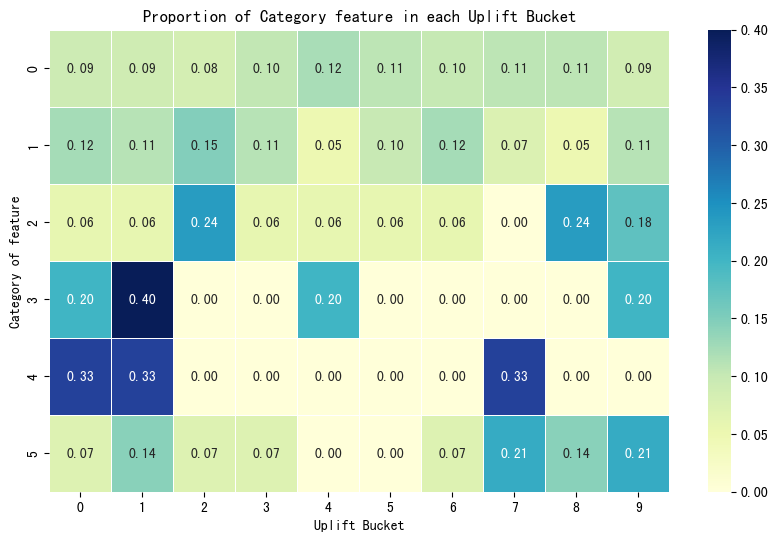

------{治疗时B症状(0:无；1:有)}------
{0.0: 0, 1.0: 1, nan: 2}


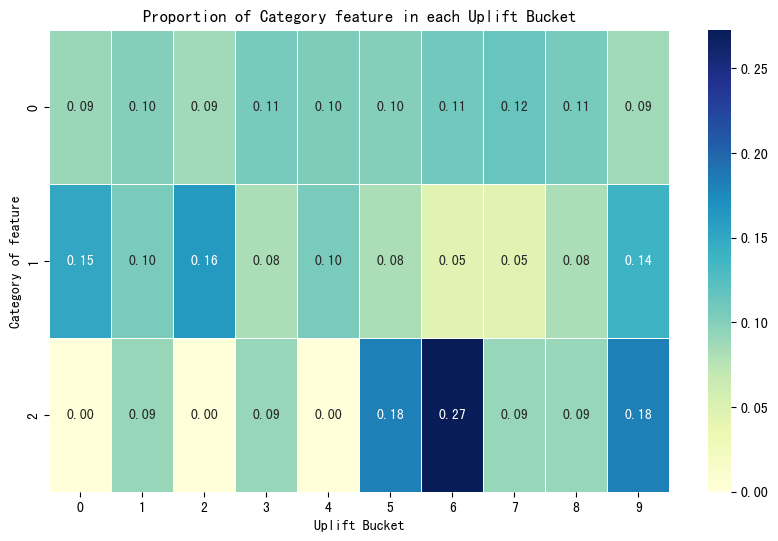

------{首次开始治疗前分期（一般1-2称为局限期，3-4进展期）}------
{0.0: 0, 1.0: 1, 2.0: 2, 3.0: 3, 4.0: 4, nan: 5}


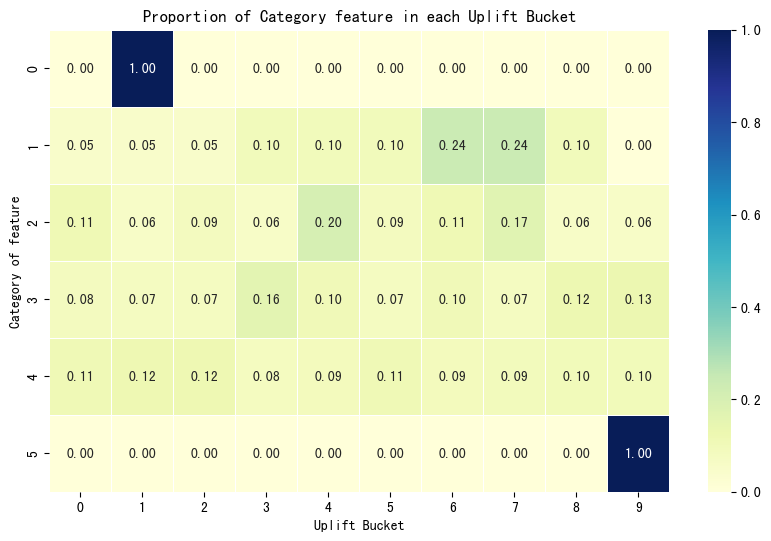

------{治疗时是否骨髓受累（骨髓穿刺明确，有是预后不良因素）}------
{0.0: 0, 1.0: 1, nan: 2}


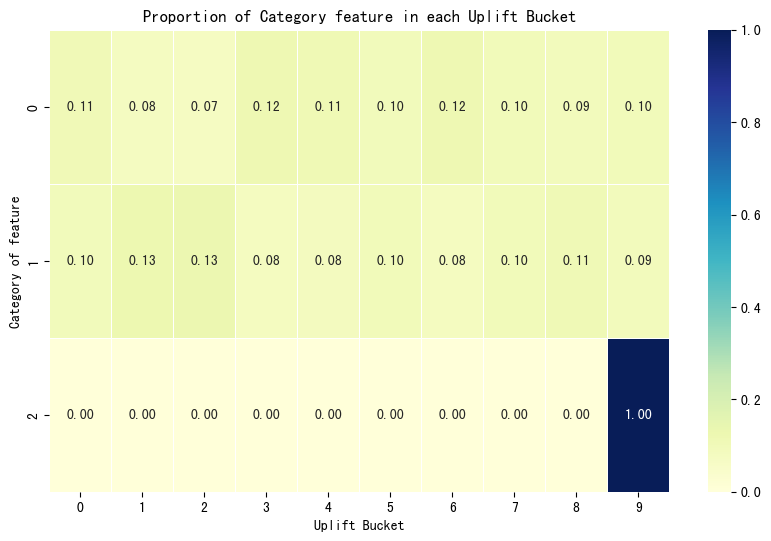

------{治疗时单个淋巴结是否大于6cm（大于6预后不良因素）}------
{0.0: 0, 1.0: 1, nan: 2}


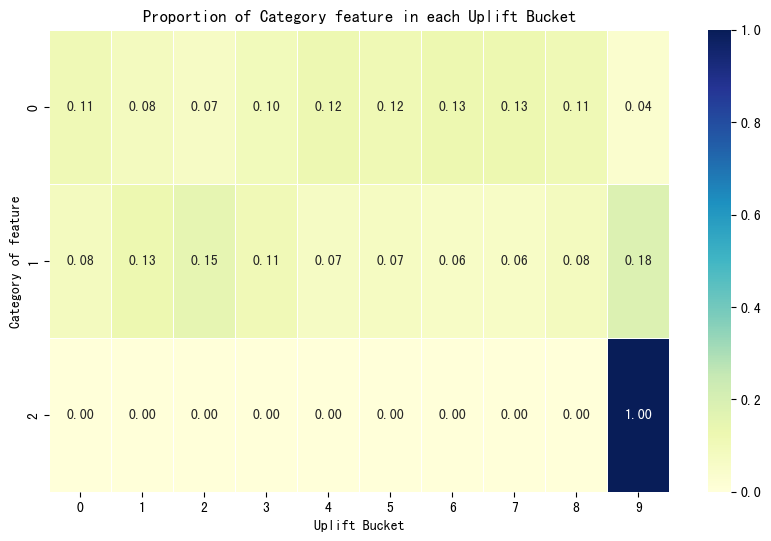

------{分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症)}------
{1: 0, 3: 1, 4: 2, 6: 3, 9: 4, 10: 5, 11: 6}


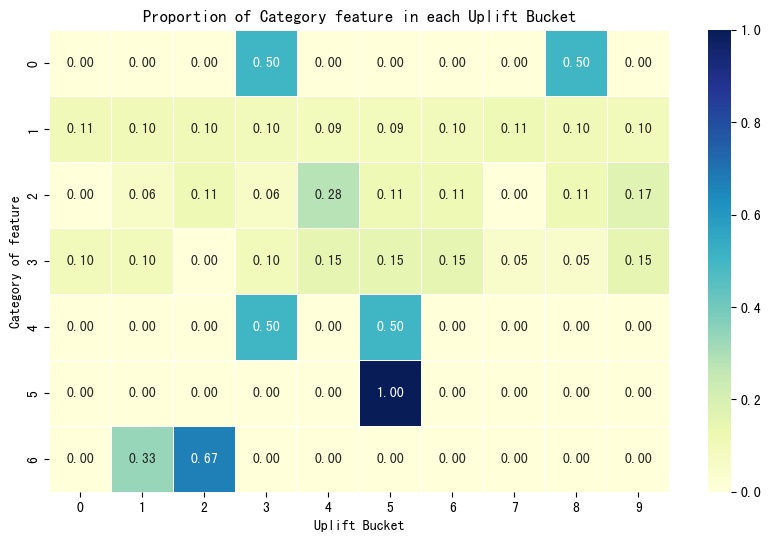

------{评效分组1}------
{'CR': 0, 'PD': 1, 'PR': 2, 'SD': 3, nan: 4}


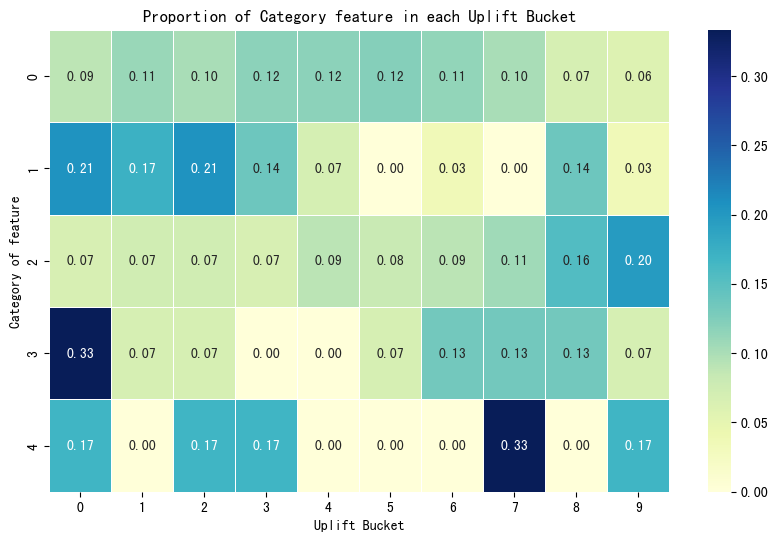

------{启动一线治疗原因（新补充）}------
{4.0: 0, nan: 1}


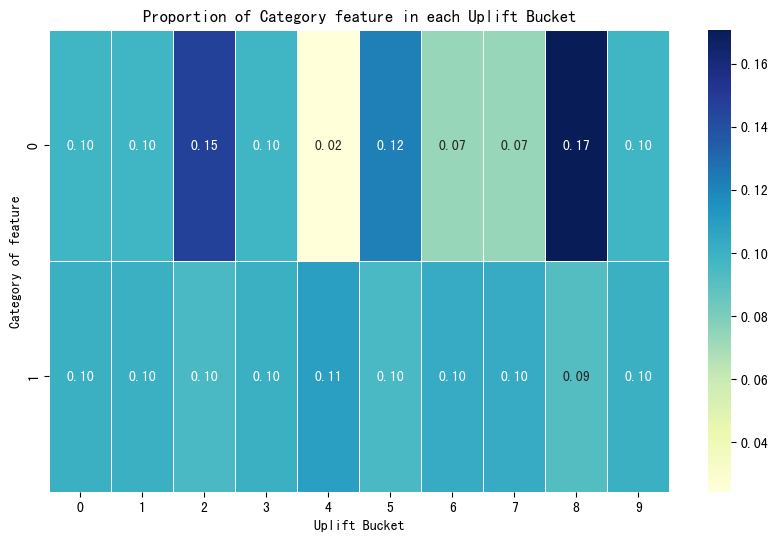

In [46]:
import seaborn as sns
def vis_cls_of_uplift_bucket(df, f, bucket):
    # 计算每个类别在每个 bucket 中的占比
    category_bucket_counts = df.groupby([f, bucket]).size().unstack(fill_value=0)
    category_proportions = category_bucket_counts.div(category_bucket_counts.sum(axis=1), axis=0)

    # 绘制热力图
    plt.figure(figsize=(10, 6))
    sns.heatmap(category_proportions, cmap="YlGnBu", linewidths=0.5, annot=True, fmt=".2f")
    plt.xlabel('Uplift Bucket')
    plt.ylabel('Category of feature')
    plt.title('Proportion of Category feature in each Uplift Bucket')
    plt.show()

for f in cate_features:
    print('------{%s}------'%f)
    print(labelEncoderDict[f])
    vis_cls_of_uplift_bucket(df_filtered, f, 'bucket')

In [47]:
# 按 uplift 列进行排序
df_sorted = df_filtered.sort_values(by='uplift', ascending=False)

# 根据 R 维持列进行分组
groups = df_sorted.groupby('Rweichi')

final_result = []

# 对于每个分组
for group_name, group_data in groups:
    # 从每个分组中选择 uplift 最高的五行和最低的五行，并合并在一起
    top_rows = group_data.head(5)
    bottom_rows = group_data.tail(5)
    combined_rows = pd.concat([top_rows, bottom_rows])
    final_result.append(combined_rows)

# 将结果合并成一个 DataFrame
result_df = pd.concat(final_result).sort_values(by=['bucket','Rweichi'], ascending=False)

result_df['ID']


419    T001475117
278    T001077783
321    T001395756
194    T001044387
283    T001716303
11     T001643309
149    T001193047
113    T001224389
185    0009612030
191    T000998172
235    T001382644
290    T001540954
214    T001468294
410    T001753900
215    T001753900
275    T001715919
386    T001520625
209    T001680311
326    T000976127
310    T001584239
Name: ID, dtype: object

In [45]:
result_df.to_csv('case_study.csv', encoding='utf-8')

In [46]:
# 将 df_filtered 中的 'ID' 列与 result_df 中的 'ID' 列进行合并
merged_df_filtered = pd.merge(df_filtered, result_df[['ID']], on='ID', how='inner')

# 输出合并后的 DataFrame df_filtered
merged_df_filtered
merged_df_filtered.to_csv('case_study.csv', encoding='utf-8')

In [47]:
df_filtered['性别（0:女；1:男）'].value_counts()

0    215
1    194
Name: 性别（0:女；1:男）, dtype: int64

In [48]:
without_rweichi_list = ['T000313630',
'T001123294',
'0009590779',
'T001172296',
'T001121506',
'T001068376',
'T001173744',
'T000922095',
'T001195839',
'T001248114']
filtered_rows = df_filtered[df_filtered['ID'].isin(without_rweichi_list)]
filtered_rows

,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,Rweichi,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,pod24,uplift,predict_y,bucket
71,T000922095,1,4.0,NaN,0,1,3,62.0,0,7.0,...,1,3,0,0,86.166667,1,0,-0.046916,0.087445,4
121,T001248114,1,4.0,NaN,0,0,1,46.0,2,1.0,...,1,1,0,0,50.066667,0,0,0.000977,0.042729,7
123,T001195839,1,2.0,NaN,0,0,0,36.0,2,1.0,...,1,1,0,0,78.800000,0,0,-0.132285,0.047864,1
124,T000313630,0,4.9,21.90,0,0,2,67.0,0,2.0,...,1,1,0,0,68.400000,0,0,-0.164136,0.118845,0
156,T001123294,0,5.2,17.90,0,0,3,37.0,2,5.0,...,1,1,0,1,62.333333,0,0,-0.053789,0.080632,3
162,0009590779,0,3.1,NaN,0,0,3,26.0,2,10.0,...,1,1,0,0,103.700000,1,0,0.068940,0.066965,8
247,T001172296,1,3.7,12.65,1,0,3,50.0,0,5.0,...,1,1,0,0,66.766667,0,0,-0.088812,0.049454,2
264,T001121506,0,4.7,10.90,0,0,4,40.0,0,12.0,...,1,1,0,0,98.733333,0,0,-0.010885,0.057494,6
374,T001068376,0,3.5,4.40,1,2,1,47.0,0,1.0,...,1,1,0,1,120.966667,0,0,-0.125512,0.209536,1
396,T001173744,1,3.0,7.30,0,0,1,57.0,2,1.0,...,1,4,0,0,66.566667,0,0,-0.073441,0.046830,3


In [49]:
filtered_rows.to_csv('case_study_doctor.csv', encoding='utf-8')

In [50]:
data_shap = df_filtered[df_filtered['β2微球蛋白β2-MG（首次治疗）>3是预后不良因素'] > 4.9]
# data_shap['β2微球蛋白β2-MG（首次治疗）>3是预后不良因素']
data_shap

,ID,性别（0:女；1:男）,最大病灶cm（首次治疗）,SUVmax（首次治疗）,治疗时ECOG（体力评分，一般>2是预后不良因素）,治疗时B症状(0:无；1:有),首次开始治疗前分期（一般1-2称为局限期，3-4进展期）,启动一线治疗年龄（一般60为cutoff）,一线治疗时病理分级（绝大多数是1-2级和3a级，少数3b级和转化为大B细胞的）,一线治疗时累及淋巴结区数目（大于等于5预后不良）,...,启动一线治疗原因（新补充）,分类1(1-chop;2-fc;3-rchop;4-rfc;5-cvp;6-rcvp;7-放疗；8-R单药；9-放化疗；10-RB;11-GCHOP;12-WW;13-姑息对症),评效分组1,Rweichi,一线PFS(确诊时间-进展时间，需要写函数),一线后是否进展,pod24,uplift,predict_y,bucket
11,T001643309,1,16.00,NaN,1,1,4,53.0,0,9.0,...,1,1,2,0,31.800000,1,0,0.437603,0.583109,9
28,T001486423,0,NaN,NaN,0,0,4,58.0,0,8.0,...,0,1,2,1,16.200000,1,1,0.043755,0.889224,8
30,T001412577,1,8.00,NaN,1,0,3,34.0,0,8.0,...,1,1,0,1,15.933333,1,1,0.156392,0.848945,9
31,T000915198,0,10.30,NaN,0,1,4,58.0,0,10.0,...,1,1,0,1,38.400000,0,0,0.011418,0.439821,7
38,T001593801,0,NaN,NaN,1,2,4,50.0,2,6.0,...,1,2,0,0,9.433333,1,1,-0.023809,0.459290,5
41,T001635787,0,5.30,NaN,0,2,3,44.0,0,7.0,...,1,1,2,1,20.533333,1,1,0.063577,0.892831,8
66,T001620962,1,6.00,NaN,0,0,3,43.0,0,7.0,...,0,1,4,0,17.366667,1,0,0.114850,0.678938,9
81,T000444943,0,5.40,NaN,0,0,4,55.0,0,3.0,...,1,3,2,1,9.933333,1,1,0.095018,0.819927,9
85,T001563552,0,NaN,NaN,1,1,3,46.0,0,5.0,...,1,1,2,0,5.100000,1,1,-0.030835,0.902538,5
86,T001646638,1,12.20,NaN,4,0,4,62.0,2,6.0,...,1,1,4,0,6.833333,1,1,0.023927,0.950532,7



A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


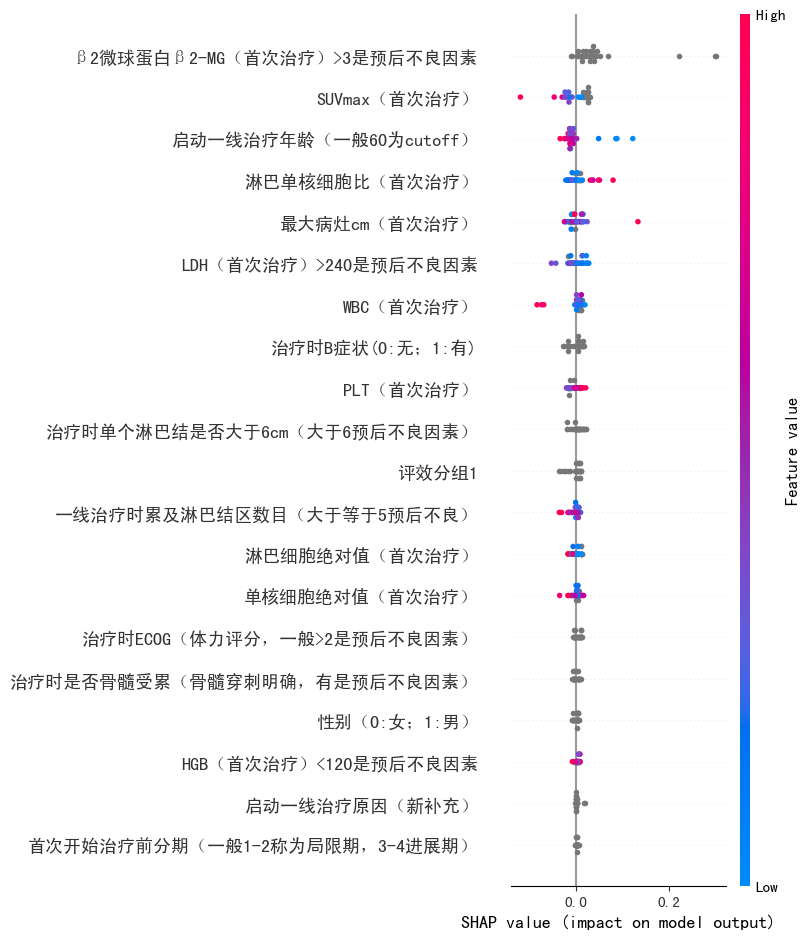

In [51]:
import shap
from catboost import CatBoostClassifier

# 计算 uplift
data_shap['uplift'] = DML.predict(data_shap)

explainer = shap.Explainer(DML.res_model)
shap_values = explainer(data_shap[DML.features])

shap.summary_plot(shap_values, data_shap[DML.features])

# 对单个样本进行解释
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values.values[4], data_shap[DML.features].iloc[4])


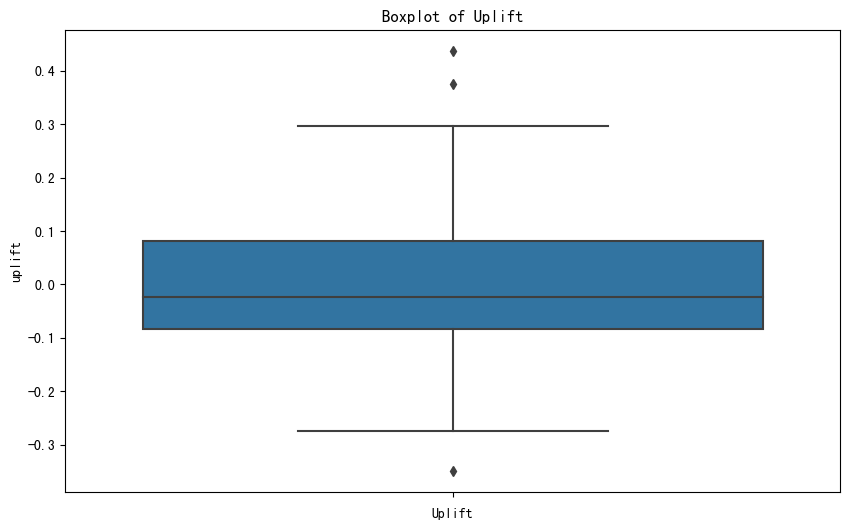

In [52]:
# 绘制箱线图
plt.figure(figsize=(10, 6))
sns.boxplot(y=data_shap['uplift'])
plt.xlabel('Uplift')
plt.title('Boxplot of Uplift')

# 显示图形
plt.show()